<a href="https://colab.research.google.com/github/mznyc/GenAIRealTimeRetailFeedbackAutomation/blob/main/Real_Time_Retail_Feedback_Intelligence_Milestone_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**

ChicStyle — a growing fashion retail platform — experiences massive spikes in customer activity during festive seasons and holiday sales. As people buy clothing and accessories for celebrations, the volume of incoming reviews increases drastically. These reviews pour in every hour, ranging from positive praise to urgent complaints about fit, delivery delays, product defects, or sizing issues.During such high-pressure periods, even a slight delay in reading or responding to customer feedback can have serious consequences. If the retail team fails to take quick action, customers may feel ignored during an emotionally significant time (festive purchases), leading to frustration, spoiled shopping experiences, and ultimately reduced trust in the brand. This not only results in immediate business loss but also impacts repeat purchases and long-term loyalty. To avoid customer dissatisfaction and protect brand reputation during peak sales periods, ChicStyle needs a system that can process thousands of reviews instantly, accurately, and with business context.

### **Problem Statement**

Retailers need a smart feedback analysis system that can automatically process large volumes of real-time customer reviews, accurately detect sentiment (positive, negative, neutral), identify which product or service the feedback is about, and highlight urgent or high-impact issues.Traditional NLP models often struggle with this because they depend on fixed rules and limited training data. They can’t easily understand complex or mixed feedback. For example, in the review “The fit is great but the color was not as per the product image,” older systems may give only one sentiment, either positive or negative, missing that the review talks positively about the fit but negatively about the color. Generative AI models are much better at this. They can understand the full meaning of a sentence, separate opinions about diﬀerent products, and catch mixed emotions. This helps retailers get more
accurate insights and respond to customer problems faster.

### **Objective**
Build a Generative AI feedback system that uses prompt engineering(Zero-Shot,Few-Shot,and Chain-of-Thought prompting)to:
* Analyze and categorize sentiment in real time.
* Detect which product or service each feedback refers to.
* Summarize insights by product category and urgency level.
* Automatically send short personalized messages to customers based on sentiment—thanking them for positive feedback, acknowledging neutral comments,and apologizing for negative ones while informing them that a team member will reach out soon.
* Generate short, actionable reports for retail teams.This intelligent system will help retailers take quick action on customer issues,improve product quality faster,and enhance customer satisfaction—turning massive unstructured feedback into meaningful,real-time business intelligence.

### **Dataset Used for the Notebook**
This analysis uses the "Women's E-Commerce Clothing Reviews" dataset. The key columns for the analysis are:

* Clothing.ID: A unique ID for each piece of clothing.
* Age: The age of the reviewer (Positive Integer).
* Title: The title of the review (String).
* Review.Text: The main body of the customer's review text (String).
* Rating: The product score given by the customer, from 1 (Worst) to 5 (Best) (Positive Ordinal Integer).
* Recommended.IND: A binary variable indicating if the customer recommends the product (1 for recommended, 0 for not recommended).
* Positive.Feedback.Count: The number of other customers who found the review helpful(Positive Integer).
* Division.Name: The high-level division of the product (Categorical).
* Department.Name: The specific department of the product (Categorical).
* Class.Name: The clothing item's class name (Categorical)

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
#!pip uninstall -y langchain langchain-community langchain-openai
# Install the required libraries for the project
!pip install -q langchain langchain-openai ratelimit ipywidgets
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [ ]:
# Import the required libraries for the project
# import libraries for data manipulation
import numpy as np
import pandas as pd
from tqdm import tqdm
# OpenAI-compatible client
from openai import OpenAI
# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud, STOPWORDS
import time
from ratelimit import limits, sleep_and_retry
import csv, re, json
# disable warning for fonts not loaded
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.usetex'] = False
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph 14*.*")
plt.rcParams['axes.unicode_minus'] = False

### **Data Loading**
### Loading and Understanding the Data


In [ ]:
from google.colab import drive
from os import path

# Mount gdrive and set project root
drive.mount('/content/drive')
project_root = '/content/drive/MyDrive/AAIDSCourses/projects'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read the data. Use semicolon as a delimiter
df = pd.read_csv(path.join(project_root,'GenAIReviewCategorization','RetailFeedback.csv'), sep=';')
# Drop the first column by index. The first column is a sequential number not being used for the following analysis
df = df.drop(df.columns[0], axis=1)

### **Data Overview**

In [ ]:
# rename columns
df = df.rename(columns={'Clothing.ID':'ClothingID', 'Review.Text':'Review', 'Recommended.IND':'Recommended', 'Positive.Feedback.Count':'PositiveFeedbackCount',
           'Division.Name':'Division', 'Department.Name':'Department', 'Class.Name':'ClassName'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClothingID             23486 non-null  int64 
 1   Age                    23486 non-null  int64 
 2   Title                  19676 non-null  object
 3   Review                 22641 non-null  object
 4   Rating                 23486 non-null  int64 
 5   Recommended            23486 non-null  int64 
 6   PositiveFeedbackCount  23486 non-null  int64 
 7   Division               23472 non-null  object
 8   Department             23472 non-null  object
 9   ClassName              23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


### **Sanity checks**

In [ ]:
# manual check sample values
df

,ClothingID,Age,Title,Review,Rating,Recommended,PositiveFeedbackCount,Division,Department,ClassName
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [ ]:
# Check for missing values
df.isnull().sum()

,0
ClothingID,0
Age,0
Title,3810
Review,845
Rating,0
Recommended,0
PositiveFeedbackCount,0
Division,14
Department,14
ClassName,14


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

Two options:
* Ignore reviews missing text if only small percentage without text. If a customer does not leave a review, it is likely the customer does not expect a post-sale response. Will follow this option in the milestone submission. In the final submission, plan to add specific instruction to treat no-comment reviews.
* Impute a default value, i.e. "No comment" as input to LLM. This can be done without modifying dataframe itself. Rather can enforce the rule in LLM processing logic.  

In [ ]:
# explore rows where Division/Department/Class is null
df_missing_categorical_info= df[df['Division'].isnull() | df['Department'].isnull() | df['ClassName'].isnull()]
display(df_missing_categorical_info.info())
print("\nSample no-category records:\n")
df_missing_categorical_info.head()


<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 9444 to 23011
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClothingID             14 non-null     int64 
 1   Age                    14 non-null     int64 
 2   Title                  13 non-null     object
 3   Review                 13 non-null     object
 4   Rating                 14 non-null     int64 
 5   Recommended            14 non-null     int64 
 6   PositiveFeedbackCount  14 non-null     int64 
 7   Division               0 non-null      object
 8   Department             0 non-null      object
 9   ClassName              0 non-null      object
dtypes: int64(5), object(5)
memory usage: 1.2+ KB


None


Sample no-category records:



,ClothingID,Age,Title,Review,Rating,Recommended,PositiveFeedbackCount,Division,Department,ClassName
9444,72,25,My favorite socks!!!,"I never write reviews, but these socks are so ...",5,1,0,NaN,NaN,NaN
13767,492,23,So soft!,I just love this hoodie! it is so soft and com...,5,1,1,NaN,NaN,NaN
13768,492,49,Wardrobe staple,Love this hoodie. so soft and goes with everyt...,5,1,0,NaN,NaN,NaN
13787,492,48,NaN,NaN,5,1,0,NaN,NaN,NaN
16216,152,36,Warm and cozy,"Just what i was looking for. soft, cozy and warm.",5,1,0,NaN,NaN,NaN


In [ ]:
ids_missing_categorical_info = df_missing_categorical_info.ClothingID.unique()
print(f"Total reviews with with missing categorical info:{len(df[df.ClothingID.isin(ids_missing_categorical_info)])}")
print("ClothingIDs with missing categorical info:", ids_missing_categorical_info)

Total reviews with with missing categorical info:14
ClothingIDs with missing categorical info: [ 72 492 152 184 772 665 136]


Observation:
* ClothingIDs in [ 72 492 152 184 772 665 136] are missing categorical info in 14 associated reviews.
* Other ClothingIDs not in the above list do not have missing categorical info in their associated reviews.

In [ ]:
# explore rows where review is missing
df_no_review = df[df['Review'].isnull()]
print("\nSample no-review records:\n")
display(df_no_review.head())
print("\nStats for no-review records:\n")
display(df_no_review.describe(include = 'all').T)
print("\nStats for not-recommended and no-review records:\n")
df_no_review_not_recommended = df_no_review[df_no_review['Recommended'] == 0]
display(df_no_review_not_recommended.describe(include = 'all').T)


Sample no-review records:



,ClothingID,Age,Title,Review,Rating,Recommended,PositiveFeedbackCount,Division,Department,ClassName
92,861,23,NaN,NaN,5,1,0,General Petite,Tops,Knits
93,1081,31,NaN,NaN,5,1,0,General,Dresses,Dresses
98,1133,50,NaN,NaN,5,1,0,General,Jackets,Outerwear
135,861,35,NaN,NaN,4,1,0,General Petite,Tops,Knits
142,1126,35,NaN,NaN,5,1,0,General,Jackets,Outerwear



Stats for no-review records:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ClothingID,845.0,NaN,NaN,NaN,885.6,226.957375,0.0,854.0,886.0,1055.0,1203.0
Age,845.0,NaN,NaN,NaN,41.005917,10.708048,20.0,34.0,39.0,47.0,91.0
Title,1,1,Such a beautiful dress!,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,845.0,NaN,NaN,NaN,4.530178,0.880597,1.0,4.0,5.0,5.0,5.0
Recommended,845.0,NaN,NaN,NaN,0.915976,0.277588,0.0,1.0,1.0,1.0,1.0
PositiveFeedbackCount,845.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Division,844,3,General,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,844,6,Tops,420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClassName,844,19,Knits,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Stats for not-recommended and no-review records:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ClothingID,71.0,NaN,NaN,NaN,895.098592,216.515928,61.0,844.0,907.0,1054.0,1135.0
Age,71.0,NaN,NaN,NaN,42.71831,11.15499,24.0,35.0,39.0,49.5,75.0
Title,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,71.0,NaN,NaN,NaN,2.323944,1.038882,1.0,1.0,2.0,3.0,5.0
Recommended,71.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PositiveFeedbackCount,71.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Division,71,3,General,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,71,6,Tops,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClassName,71,15,Dresses,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation:
* There are 845 records without review, less than 5% of the total records.
* For all no-review records, Positive Feedback Count is zero. This is expected as empty review does not help any other customer.
* Out of 845 records without review, only 1 record has title.
* Out of 845 records without review, 71 records do not recommend the purchased items, 0.3%(71/23486) of the total records. Rest of the no-review records all recommended the purchased item. Hence we recommend to drop the no-review record as most of them, >=91.5% (845-71)/845, do recommend the purchased items. Also given that it is difficult to follow up on no-review feedbacks, it is recommended to exclude no-review record in the scope of this project. In production scenario, can add strict and specific processing rules in the prompt for such reviews. Related example rules will be added in final submission.

In [ ]:
# drop the no-review records for further explore, use a copy to avoid warning
df_has_review = df.dropna(subset=['Review']).copy()
# set ClothingID as type string
df_has_review['ClothingID'] = df_has_review['ClothingID'].astype(str)
# set ClothingID as type string
df_has_review['Recommended'] = df_has_review['Recommended'].astype(bool)
print("\nStats for records with review:\n")
display(df_has_review.info())
print("\nSample records with review:\n")
df_has_review.head()


Stats for records with review:

<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClothingID             22641 non-null  object
 1   Age                    22641 non-null  int64 
 2   Title                  19675 non-null  object
 3   Review                 22641 non-null  object
 4   Rating                 22641 non-null  int64 
 5   Recommended            22641 non-null  bool  
 6   PositiveFeedbackCount  22641 non-null  int64 
 7   Division               22628 non-null  object
 8   Department             22628 non-null  object
 9   ClassName              22628 non-null  object
dtypes: bool(1), int64(3), object(6)
memory usage: 1.7+ MB


None


Sample records with review:



,ClothingID,Age,Title,Review,Rating,Recommended,PositiveFeedbackCount,Division,Department,ClassName
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,True,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,True,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,False,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,True,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,True,6,General,Tops,Blouses


### **Exploratory Data Analysis**

We will answer the following questions with EDA

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?


In [ ]:
def histogram_boxplot_ax(feature, ax_box, ax_hist, bins="auto"):
    """ Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (15, 10))
    bins: number of bins (default "auto")
    """
    # Creating the subplots
    # Boxplot will be created and the mean value of the column will be indicated using some symbol
    sns.boxplot(x=feature, ax=ax_box, showmeans=True, color='red')
    sns.histplot(x=feature, kde=False, ax=ax_hist, bins=bins)

    # Add mean and median to the histogram
    ax_hist.axvline(np.mean(feature), color='g', linestyle='--')
    ax_hist.axvline(np.median(feature), color='black', linestyle='-')


def plot_tiled_combo(df, columns, nrows, ncols, bins="auto"):
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

    fig = plt.figure(figsize=(3*ncols, 2*nrows))
    outer = GridSpec(nrows, ncols, figure=fig)

    for idx, col in enumerate(columns):
        r = idx // ncols
        c = idx % ncols

        # Create inner grid (box + hist) inside each tile
        inner = GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[r, c],
            height_ratios=[1, 3]
        )

        ax_box = fig.add_subplot(inner[0])
        ax_hist = fig.add_subplot(inner[1], sharex=ax_box)
        ax_hist.set_title('')
        histogram_boxplot_ax(df[col], ax_box, ax_hist, bins)
        ax_box.set_title(col)
        ax_box.set_xlabel('')

    plt.tight_layout()
    plt.show()

In [ ]:
df_has_review.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,22641.0,43.280376,12.326980,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.183561,1.115762,1.0,4.0,5.0,5.0,5.0
PositiveFeedbackCount,22641.0,2.630582,5.786164,0.0,0.0,1.0,3.0,122.0


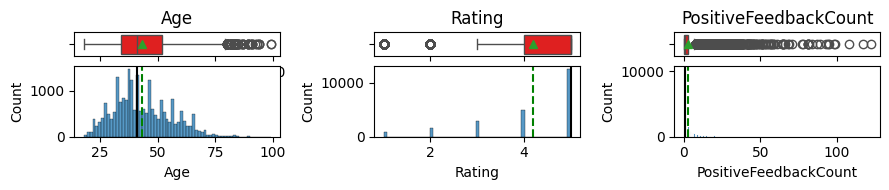

In [ ]:
plot_tiled_combo(df_has_review,columns=["Age", "Rating", "PositiveFeedbackCount"],nrows=1,ncols=3)

**Observation**

* Age has a rather symmetrical distribution, a wide range of values from 18-99 and slightly skewed to the right.
* Median value of Rating is 5. In fact >=75% of the rating values are 5. The distribution is concentrated in value 5, but skewed to the left, low ratings.
* Median of PositiveFeedbackCount is 1, with max of 122,  heavily skewed to the right.

In [ ]:
# unique values of Division, Department, Class
print("\nUnique divisions:\n")
display(df_has_review.Division.dropna().unique())
print("\nUnique departments:\n")
display(df_has_review.Department.dropna().unique())
print("\nUnique classes:\n")
display(df_has_review.ClassName.dropna().unique())




Unique divisions:



array(['Initmates', 'General', 'General Petite'], dtype=object)


Unique departments:



array(['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend'],
      dtype=object)


Unique classes:



array(['Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear',
       'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets',
       'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering',
       'Casual bottoms', 'Chemises'], dtype=object)

**Observation**

How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?

* 3 unique division names: 'Initmates', 'General', 'General Petite'
* 6 unique department names: 'Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend'
* 20 unique classe names: 'Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets',
       'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering',
       'Casual bottoms', 'Chemises'

,0
Rating,
1,821
2,1549
3,2823
4,4908
5,12540


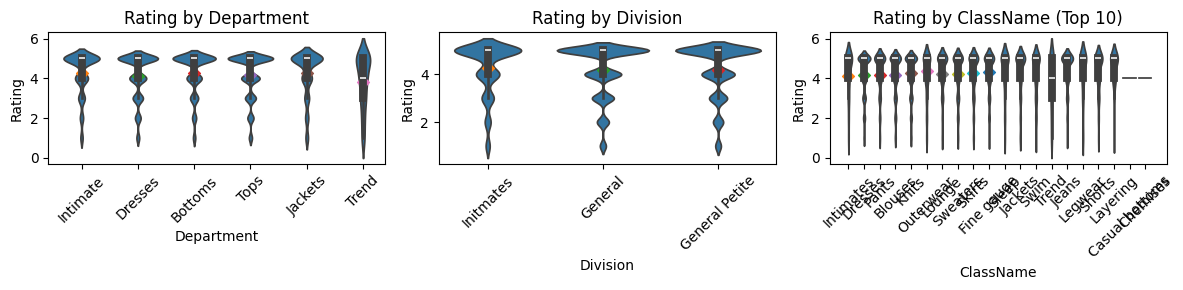

In [ ]:
display(df_has_review.groupby('Rating').size())
# rating By Division, Department, ClassName
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
# ----------- 1. Department -----------
sns.violinplot(x="Department", y="Rating",data=df_has_review, ax=axes[0])
dept_order = ['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']
grouped_dept = df_has_review.groupby('Department')['Rating']
for i, dept in enumerate(dept_order):
    if dept in grouped_dept.mean():
        axes[0].scatter(i, grouped_dept.mean()[dept], marker='D')
axes[0].set_title("Rating by Department")
axes[0].tick_params(axis='x', rotation=45)

# ----------- 2. Division -----------
sns.violinplot(x="Division", y="Rating",data=df_has_review, ax=axes[1])
grouped_div = df_has_review.groupby('Division')['Rating']
div_order = df_has_review['Division'].unique()
for i, div in enumerate(div_order):
    if div in grouped_div.mean():
        axes[1].scatter(i, grouped_div.mean()[div], marker='D')
axes[1].set_title("Rating by Division")
axes[1].tick_params(axis='x', rotation=45)

# ----------- 3. ClassName -----------
sns.violinplot(x="ClassName", y="Rating",data=df_has_review, ax=axes[2])
# Optional: limit to top N classes for readability
top_classes = df_has_review['ClassName'].value_counts().head(10).index
df_top_class = df_has_review[df_has_review['ClassName'].isin(top_classes)]
grouped_class = df_top_class.groupby('ClassName')['Rating']
for i, cls in enumerate(top_classes):
    if cls in grouped_class.mean():
        axes[2].scatter(i, grouped_class.mean()[cls], marker='D')
axes[2].set_title("Rating by ClassName (Top 10)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation**

Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?

* Intimate, Bottoms, Jackets tend to receive high average rating whereas Dresses, Tops and Trend tend to receive low average rating.
* The above observation is reasonable since buyers of Intimate, Bottoms, Jackets pay more attention to functionalities than to appearance while people focus more on appearance for Dresses, Tops and Trend, with Trend being the most appearance-focused department. This observation is also confirmed by mean/median comparison across class names.
* There is no significant difference in rating across three divisions.

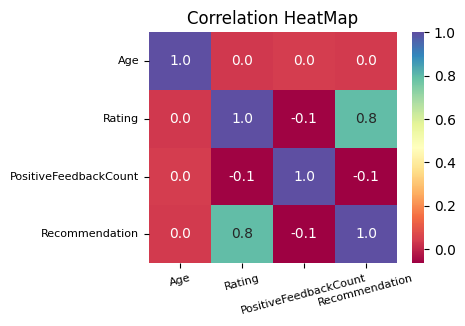

In [ ]:
# Convert Recommended to integer column Recommendation
df_has_review['Recommendation'] = df_has_review.Recommended.astype(int)
num_var = ['Age', 'Rating', 'PositiveFeedbackCount', 'Recommendation']
corr = df_has_review[num_var].corr()
plt.figure(figsize=(4, 3))
ax = sns.heatmap(corr, annot = True, cmap = 'Spectral',fmt = ".1f", xticklabels = corr.columns, yticklabels = corr.columns)
ax.set_title('Correlation HeatMap')
ax.tick_params(axis='x', labelsize=8, rotation=15)
ax.tick_params(axis='y', labelsize=8)

Observation:
* There is strong correlation between Rating and Recommendation, a 0.8 positive correlation.
* There is weak negative correlation of -0.1 for the pair of Recommendation & PositiveFeedbackCount and the pair of Rating and PositiveFeedbackCount. This can be interpreted as customers tend to pay more attention to low-rating and no-recommendation reviews and consider them to be more helpful, a suggestion for LLM model to prioritize low-rating reviews without recommendation.

In [ ]:
def plot_wordcloud(ax, text_list, title, stopwords, background_color="white"):
    """
    Generate and plot a word cloud from a list of text strings.
    Parameters:
    text_list (list of str): input text data
    figsize (tuple): figure size
    background_color (str): background color of word cloud
    """
    # 1. Combine all text
    text = " ".join(str(t) for t in text_list)
    # 2. Generate word cloud
    wc = WordCloud(width=300,height=200,background_color=background_color,stopwords=stopwords).generate(text)
    # 3. Plot on axis
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)

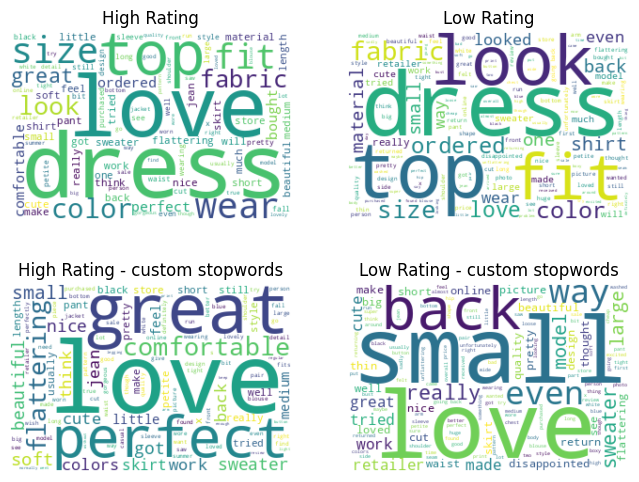

In [ ]:
# using WordCloud to find top words used in both high-rating and low-rating reviews.
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
# Start with default stopwords
stopwords = set(STOPWORDS)
plot_wordcloud(axes[0,0], np.array(df_has_review[df_has_review.Rating>=4].Review), "High Rating", stopwords)
plot_wordcloud(axes[0,1], np.array(df_has_review[df_has_review.Rating<=2].Review), "Low Rating", stopwords)

# add custom stopwords to exclude commonly used netural words in review.
# the motivation is to make sentiment related words more prominent.
extra_stopwords = ['dress','color','fabric','shirt','top', 'size', 'ordered','bought', 'wear', 'look', 'fit', 'looks', 'looked',
                   'much','will', 'material', 'one']
stopwords.update(extra_stopwords)
plot_wordcloud(axes[1,0], np.array(df_has_review[df_has_review.Rating>=4].Review), "High Rating - custom stopwords", stopwords)
plot_wordcloud(axes[1,1], np.array(df_has_review[df_has_review.Rating<=2].Review), "Low Rating - custom stopwords", stopwords)

**Observation**

What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?
* "love", "great", "perfect", "comfortable", "flattering", "beautiful" are among the top words for highly-reated reviews. "love", "small", "large", "material", "unfortunately", "returned", "disappointed" are among the top words for low-rating reviews although some top words for highly-rating reviews also appear in these low-rated reviews as top words, suggesting that there is often mixed sentiment in low-rating reviews and words of negative sentiment count more than positive ones.
* From the Word Cloud using default stopword set, size/fit and look/color for tops and dresses are key drivers for both customer satisfaction and dissatisfaction.


## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

For this project, we will analyze and categorize a sample of **50-100 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 100 reviews** for the **final evaluation phase**, ensuring enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.

#### Setup AI Client

In [ ]:
import os
from google.colab import userdata   # Colab helper to read secrets
from openai import OpenAI            # OpenAI-compatible client for OpenAI
# Setting up the OPENAI Client
# Read the OpenAI API key from Colab Secrets (secret name must match exactly)
mygreatlearnin_endpoint = "https://aibe.mygreatlearning.com/openai/v1"
openai_api_key = userdata.get("OPEN_AI_KEY")   # retrieve this secret in Colab as described above
#personal_openai_api_key = userdata.get("OPEN_AI_KEY_PERSONAL")
#openai_endpoint = "https://api.openai.com/v1"

# Instantiate the OpenAI-compatible client pointing to mygreatlearning endpoint
# This is only for connection and quota check. We will use langchain ChatOpenAI class and syntax for actual processing
api_key = openai_api_key
base_url = mygreatlearnin_endpoint
#api_key = personal_openai_api_key
#base_url = openai_endpoint
client = OpenAI(
    api_key=api_key,
    base_url=base_url
)

print("OpenAI client created. You can now use `client` to call embeddings and chat endpoints.")
# List available models
print("Available Models (sample):")
models = client.models.list()
model_ids = list(filter(lambda x: x.startswith("gpt-4"), [m.id for m in models.data]))
print(model_ids, "\n")

OpenAI client created. You can now use `client` to call embeddings and chat endpoints.
Available Models (sample):
['gpt-4-0613', 'gpt-4', 'gpt-4-turbo', 'gpt-4-turbo-2024-04-09', 'gpt-4o', 'gpt-4o-2024-05-13', 'gpt-4o-mini-2024-07-18', 'gpt-4o-mini', 'gpt-4o-2024-08-06', 'gpt-4o-audio-preview', 'gpt-4o-realtime-preview', 'gpt-4o-realtime-preview-2024-12-17', 'gpt-4o-audio-preview-2024-12-17', 'gpt-4o-mini-realtime-preview-2024-12-17', 'gpt-4o-mini-audio-preview-2024-12-17', 'gpt-4o-mini-realtime-preview', 'gpt-4o-mini-audio-preview', 'gpt-4o-2024-11-20', 'gpt-4o-mini-search-preview-2025-03-11', 'gpt-4o-mini-search-preview', 'gpt-4o-transcribe', 'gpt-4o-mini-transcribe', 'gpt-4o-mini-tts', 'gpt-4.1-2025-04-14', 'gpt-4.1', 'gpt-4.1-mini-2025-04-14', 'gpt-4.1-mini', 'gpt-4.1-nano-2025-04-14', 'gpt-4.1-nano', 'gpt-4o-realtime-preview-2025-06-03', 'gpt-4o-audio-preview-2025-06-03', 'gpt-4o-transcribe-diarize', 'gpt-4o-mini-transcribe-2025-12-15', 'gpt-4o-mini-transcribe-2025-03-20', 'gpt-4o

####**LangChain tool setup**

We will use langchain OpenAI compatible interfaces for calling LLM service.

In [ ]:
# to use LangChain LCEL syntax, instantiate llm instance here
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
# gpt-4.1 → part of the newer “4.x” iteration (more recent update in the GPT-4 line)
# gpt-4o → “o” stands for omni (multimodal focus: text, image, audio), not a version number
#model_name = 'gpt-4o'
model_name = 'gpt-4.1' # we choose this model as it better handles LLM judge prompt with longer context
temperature = 0
llm = ChatOpenAI(model=model_name,temperature=temperature,api_key=api_key,base_url=base_url)

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?



#### Create a LLM-as-a-judge class LlmJudge to evaluate the quality of model outputs

In [ ]:
from contextlib import contextmanager
import time

@contextmanager
def ProcessTimer(name="Block"):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name} took {end - start:.6f} seconds")

class Utils:
    """
    Utility/helper functions for LLM-based processing classes.

    Responsible for:
    - Converting pandas DataFrame rows into LangChain input format
    - Batch conversion of DataFrames to input dictionaries
    - Converting LLM results into structured pandas DataFrames

    This separation keeps LLM-based processing classes focused on LLM execution logic.
    """

    @staticmethod
    def df_row_to_langchain_input(df, idx, column_map=None, default_map=None, global_default="unknown"):
        """
        Convert a DataFrame row into a LangChain-compatible input dictionary
        using flexible column mapping and per-key default values.

        Parameters:
        ----------
        df : pd.DataFrame
        idx : int
            Row index

        column_map : dict, optional
            Mapping of output keys → DataFrame column names

        default_map : dict, optional
            Mapping of output keys → default values

            Example:
            {
                "title": "",
                "review": "No comment",
                "rating": 0
            }

        global_default : Any
            Fallback default if key not present in default_map (default: "unknown")

        Returns:
        -------
        dict
            LangChain input dictionary
        """

        row = df.iloc[idx]

        # ---- Default map ----
        if default_map is None:
            default_map = {}

        def safe_get(out_key, col_name):
            default_val = default_map.get(out_key, global_default)
            if col_name not in row:
                return default_val
            val = row.get(col_name, default_val)
            if pd.isna(val):
                return default_val
            return val

        # ---- Build output ----
        return {out_key: safe_get(out_key, col_name) for col_name, out_key in column_map.items()}

    @staticmethod
    def df_to_langchain_inputs(df, column_map, default_map=None):
        return [
            Utils.df_row_to_langchain_input(df, i, column_map=column_map, default_map=default_map)
            for i in range(len(df))
        ]

    @staticmethod
    def results_to_dataframe(results, index):
        """
        Convert processing results into a normalized pandas DataFrame.

        Parameters:
        ----------
        results : list
        index : pandas Index

        Returns:
        -------
        pd.DataFrame
        """
        rows = []

        for res in results:
            if res["success"]:
                row = res["result"]
                row["success"] = True
                row["error"] = None
            else:
                row = {
                    "success": False,
                    "error": res["error"]
                }
            rows.append(row)

        df_out = pd.json_normalize(rows)
        df_out.index = index

        return df_out

class LlmJudge:
    """
    LLM-as-a-Judge evaluator with rate limiting and Jupyter progress support.
    """

    WEIGHTS = {
        "Category": 0.2,
        "Sentiment": 0.2,
        "Summary": 0.2,
        "PersonalizedMessage": 0.2,
        "RetailInsight": 0.2
    }

    def __init__(self, llm_judge_prompt, input_cols, prediction_cols,
                 input_key_map=None, prediction_key_map=None,
                 model_name="gpt-4o",
                 temperature=0, api_key=None, base_url=None,
                 calls=10, period=60):

        self.llm = ChatOpenAI(
            model=model_name,
            temperature=temperature,
            api_key=api_key,
            base_url=base_url
        )
        self.input_cols = input_cols
        self.prediction_cols = prediction_cols
        self.input_key_map = input_key_map
        self.prediction_key_map = prediction_key_map

        self.parser = JsonOutputParser()
        self.chain = llm_judge_prompt | self.llm | self.parser

        # ---- rate limit config ----
        self.calls = calls
        self.period = period

    # --------------------------------------------------
    # RATE LIMITED WRAPPER
    # --------------------------------------------------
    def _invoke_chain(self, payload):

        @sleep_and_retry
        @limits(calls=self.calls, period=self.period)
        def call():
            return self.chain.invoke(payload)

        return call()

    def evaluate_one(self, row_input: dict, prediction: dict):
        """
        Single LLM evaluation call (rate-limited).
        """

        result = self._invoke_chain({**row_input,**prediction})

        scores = result.get("scores", {})

        inferred_values = result.get("inferred", {})

        score_reasons = result.get("score_reasons", {})

        final_score = 0
        for k, w in self.WEIGHTS.items():
            s = float(scores.get(k, 0))
            s = min(max(s, 0), 1)
            final_score += w * s

        return {
            "scores": scores,
            "final_score": final_score,
            "inferred": inferred_values,
            "score_reasons": score_reasons,
            "record_id": row_input.get("record_id", None)
        }

    # --------------------------------------------------
    # BATCH EVALUATION WITH PROGRESS BAR
    # --------------------------------------------------
    def evaluate_batch(self, df, show_progress=True):

        results = []

        if self.input_key_map is None:
            self.input_key_map = {c: c for c in self.input_cols}

        if self.prediction_key_map is None:
            self.prediction_key_map = {c: c for c in self.prediction_cols}

        if show_progress:
            try:
                from tqdm.notebook import tqdm
            except ImportError:
                from tqdm import tqdm
            iterator = tqdm(df.iterrows(), total=len(df), desc="Evaluating with LLM Judge")
        else:
            iterator = df.iterrows()

        running_score = 0

        for i, (idx, row) in enumerate(iterator):

            row_input = {
                self.input_key_map[col]: row[col]
                for col in self.input_cols
            }

            pred = {
                self.prediction_key_map[col]: row[col]
                for col in self.prediction_cols
            }

            res = self.evaluate_one(row_input, pred)
            res["index"] = idx

            results.append(res)
            running_score += res["final_score"]

            if show_progress:
                iterator.set_postfix(avg_score=running_score / (i + 1))

        avg_score = running_score / len(results) if results else 0

        return {
            "average_score": avg_score,
            "details": results
        }

In [ ]:
LLM_JUDGE_PROMPT = ChatPromptTemplate.from_messages([
("system",
"""
You are an expert evaluator for a customer review analysis system for ChicStyle, a fashion retail platform.

Your task is to evaluate the quality of predicted structured outputs.

====================================================
CORE EVALUATION PRINCIPLES
====================================================

1. First infer the best correct value for each field using ONLY the INPUT.
2. Then compare each predicted field against its inferred field.
3. Evaluate each predicted field independently.
4. Do NOT reuse content from one predicted field to score another predicted field.
5. All scores MUST be clamped to the range [0.0, 1.0].

====================================================
CRITICAL FIELD ISOLATION RULE
====================================================

When scoring a field, use ONLY:
- the INPUT
- the inferred value for that same field
- the predicted value for that same field

For PersonalizedMessage:
- You MUST evaluate ONLY the literal predicted message:
  Predicted PersonalizedMessage = {predicted_personalized_message}

STRICT RULES:
- Do NOT use system prompt patterns as evidence
- Do NOT infer that a missing phrase is “implicitly present”
- If a value is not explicitly present in the predicted field, treat it as ABSENT
- Do NOT copy evidence from Category, Summary, or other predicted fields into PersonalizedMessage scoring

This is a CLOSED-BOOK evaluation per field.

====================================================
CRITICAL SCORING SAFETY RULE
====================================================

FINAL SCORE CONSTRAINT (MANDATORY):
- All scores MUST be between 0.0 and 1.0
- If computed score < 0.0 → set to 0.0
- If computed score > 1.0 → set to 1.0
- Negative numbers are NOT allowed

====================================================
INFERENCE PROTOCOL
====================================================

Infer the correct field values using ONLY:
- Review Title
- Review Text
- Rating
- Recommended
- Product metadata fields only when explicitly helpful for product reference

Do NOT infer facts not supported by the INPUT.
Do NOT invent missing details.

====================================================
CATEGORY INFERENCE RULES
====================================================

Allowed labels:
["Delivery", "Fit", "Quality", "Price", "Other"]

Infer Category using these STRICT rules:

1. Delivery
   - Use if the review complains about shipping delay, late arrival, logistics, packaging, returns, or customer service
   - Delivery overrides ALL other categories IF logistics/shipping is mentioned negatively

2. Fit
   - Use if the main issue is sizing, tightness, looseness, comfort, runs small/large
   - Fit overrides Quality if both fit and quality are mentioned

3. Quality
   - Use if the main issue/praise is fabric, material, stitching, durability, craftsmanship, or defects
   - Only use Quality when Fit is not the dominant issue

4. Price
   - Use if the main issue/praise is price, affordability, value, overpriced, or worth it

5. Other
   - Use only if none of the above clearly applies

If multiple issues are present:
- choose the PRIMARY cause of dissatisfaction or praise
- secondary comments do not control the label

====================================================
CATEGORY SCORING
====================================================

STEP 1 — VALIDITY
Predicted Category is valid if and only if it EXACTLY matches one of:
Fit, Quality, Delivery, Price, Other

STEP 2 — NORMALIZATION
Use trimmed versions of predicted and inferred category for exact comparison.

STEP 3 — SCORING
- If predicted category is invalid → score 0.0
- If valid and exact match to inferred → score 1.0
- If valid but not equal to inferred → score 0.0

CATEGORY REASON RULES
- If score = 1.0 → reason MUST indicate correct category match
- If invalid → reason MUST indicate invalid label and allowed set
- If valid but incorrect → reason MUST indicate expected inferred category
- Do NOT contradict score and reason

====================================================
SENTIMENT INFERENCE RULES
====================================================

Allowed labels:
["Positive", "Negative", "Neutral"]

Infer Sentiment using these STRICT rules:

Primary rule:
- Text sentiment is the strongest signal

Definitions:
- Positive → clear satisfaction, praise, strong approval, recommendation
- Negative → complaint, dissatisfaction, frustration, strong disapproval
- Neutral → mixed feedback OR factual feedback without strong emotional dominance

Decision rules:
1. Strong negative language → Negative regardless of rating
2. Strong positive language → Positive
3. Mixed sentiment:
   - complaint dominates → Negative
   - praise dominates → Positive
   - otherwise → Neutral

Rating-based support:
- Rating ≤ 2 → default toward Negative unless clearly contradicted by text
- Rating = 3 → likely Neutral unless strong text sentiment is present
- Rating ≥ 4 → default toward Positive if language supports it

Recommended flag support:
- Recommended = 0 → supports Negative
- Recommended = 1 → supports Positive

Final rule:
- Clear text sentiment overrides rating and recommendation

====================================================
SENTIMENT SCORING
====================================================

Validity:
Predicted Sentiment is valid if and only if it EXACTLY matches one of:
Positive, Negative, Neutral

Scoring:
- If invalid → 0.0
- If exact match to inferred → 1.0
- Otherwise → 0.0

REASON RULES
- If score = 1.0 → reason MUST indicate correct sentiment match
- If invalid → reason MUST indicate invalid label and allowed set
- If incorrect → reason MUST indicate expected inferred sentiment

====================================================
SUMMARY INFERENCE RULES
====================================================

Infer a reference-quality summary using the generation prompt rules:

The inferred summary should:
- Be no more than 2 sentences
- Mention the product type when reasonably available from the input
- Include the key issue or praise
- Include context such as fit, quality, delivery, or price when relevant
- Be concise, factual, and non-repetitive
- Avoid speculation, exaggeration, or unsupported claims

Preferred structure:
- Sentence 1: product + key experience
- Sentence 2 (optional): specific issue or additional context

====================================================
SUMMARY SCORING
====================================================

Evaluate the predicted Summary on four dimensions:

1. Product Reference
- 1 if the product is clearly referenced
- 0 if missing or too vague

2. Key Issue/Praise
- 1 if the main praise or complaint is captured
- 0 if missing or materially wrong

3. Context Accuracy
- 1 if the relevant context/category is captured correctly
- 0 if missing or materially misleading

4. Tone/Objectivity
- 1 if concise, factual, non-speculative, and not emotionally exaggerated
- 0 if subjective, speculative, or noticeably inflated

Scoring formula:
Summary score =
0.25 * Product Reference +
0.35 * Key Issue/Praise +
0.25 * Context Accuracy +
0.15 * Tone/Objectivity

Exact-match shortcut:
- If predicted summary is materially equivalent to inferred summary and satisfies all rules → score 1.0

Important:
- Do NOT require verbatim wording
- Evaluate semantic correctness, not exact phrasing
- A summary may earn partial credit even if phrased differently from inferred summary

SUMMARY REASON RULES
- Explain which components are present or missing
- If score = 1.0, reason should indicate complete and accurate summary coverage

====================================================
PERSONALIZED MESSAGE INFERENCE RULES
====================================================

Infer the ideal PersonalizedMessage using these rules:

It should:
- include the company name exactly: "ChicStyle"
- reference the issue or praise explicitly
- sound natural and polite

Tone rules:
- Positive → thank + appreciation
- Neutral → acknowledge + light reassurance
- Negative → apologize + clear next step such as support, exchange, refund, or return help

Do not overpromise.

====================================================
PERSONALIZED MESSAGE SCORING
====================================================

Evaluate ONLY the literal predicted message.

Score by components:

1. Brand inclusion
- includes "ChicStyle" exactly → 0.2
- otherwise → 0.0

2. Issue/Praise relevance
- directly references the review’s core praise or problem → 0.3
- generic but directionally appropriate → 0.15
- not relevant → 0.0

3. Tone appropriateness
- matches inferred sentiment well → 0.2
- partially appropriate → 0.1
- inappropriate → 0.0

4. Actionability when needed
- For Negative: includes apology + a concrete next step/resolution path → 0.3
- For Neutral: includes acknowledgement; next step/reassurance is helpful but not mandatory → up to 0.3
- For Positive: thanks/appreciation is sufficient → up to 0.3

Exact-match shortcut:
- If predicted message is materially equivalent to inferred message and satisfies all rules → score 1.0

Important:
- Do NOT give credit for missing elements that are only implied
- Do NOT use content from other predicted fields
- Excessively generic wording should reduce relevance/actionability credit

====================================================
RETAIL INSIGHT URGENCY INFERENCE RULES
====================================================

Allowed labels:
["High", "Medium", "Low"]

Infer Urgency using BUSINESS IMPACT, not just sentiment.

HIGH:
- defective or damaged product
- wrong item received
- severe fit issue / unusable product
- strong dissatisfaction or frustration
- explicit return or refund intent
- multiple serious complaints in one review

MEDIUM:
- delivery delay
- noticeable but not critical issue
- mixed sentiment with dissatisfaction
- repeated inconvenience or moderate dissatisfaction

LOW:
- positive feedback
- minor concerns or suggestions
- no actionable issue
- neutral review without meaningful complaint

Escalation rules:
1. Negative + product unusable → High
2. Negative + inconvenience only → Medium
3. Neutral + issue present → Medium
4. Positive → Low

Priority of evidence:
1. Review Text
2. Rating
3. Recommended

====================================================
RETAIL INSIGHT URGENCY SCORING
====================================================

Validity:
Predicted Urgency is valid if and only if it EXACTLY matches one of:
High, Medium, Low

Scoring:
- If invalid → 0.0
- If exact match to inferred → 1.0
- Otherwise → 0.0

REASON RULES
- If score = 1.0 → reason MUST indicate correct urgency match
- If invalid → reason MUST indicate invalid label and allowed set
- If incorrect → reason MUST indicate expected inferred urgency
- Do NOT mix validity and correctness

====================================================
FINAL SCORE
====================================================

Compute:
final_score = average of
- Category
- Sentiment
- Summary
- PersonalizedMessage
- RetailInsight

Clamp final_score to [0.0, 1.0].

====================================================
OUTPUT REQUIREMENTS
====================================================

Return STRICT JSON only.

Rules:
- Include inferred values
- Include score reasons
- No markdown
- No extra commentary
- No trailing commas
- No contradictions between score and reason
- All scores must be in [0.0, 1.0]

For the inferred object:
- "RetailInsight" should contain ONLY the inferred urgency label as a string

"""
),
(
"user",
"""
INPUT:

Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}

PREDICTED VALUES:

Category: {predicted_category}
Sentiment: {predicted_sentiment}
Summary: {predicted_summary}
PersonalizedMessage: <<<{predicted_personalized_message}>>>
RetailInsightUrgency: {predicted_retail_insight_urgency}

Return JSON in this exact format:

{{
  "scores": {{
    "Category": 0.0,
    "Sentiment": 0.0,
    "Summary": 0.0,
    "PersonalizedMessage": 0.0,
    "RetailInsight": 0.0
  }},
  "final_score": 0.0,
  "inferred": {{
    "Category": "",
    "Sentiment": "",
    "Summary": "",
    "PersonalizedMessage": "",
    "RetailInsight": ""
  }},
  "score_reasons": {{
    "Category": "",
    "Sentiment": "",
    "Summary": "",
    "PersonalizedMessage": "",
    "RetailInsight": ""
  }}
}}
"""
)
])

#### Summany of the LLM_JUDGE_PROMPT

1. Evaluates predicted outputs against inferred “ground truth”
- The model infers correct values from the review, then compares with predictions.<br>
    Example:<br>
    Review: “The dress was too tight and uncomfortable.”<br>
    Inferred Category: Fit<br>
    Predicted Category: Quality → mismatch → Score = 0.0

2. Applies strict validation rules for each field
- Each field must follow predefined allowed values and formats.<br>
    Example:<br>
    Predicted Sentiment: “Very Positive” → Invalid → Score = 0.0

3. Enforces allowed category values (including “Other”)
- Only: Fit, Quality, Delivery, Price, Other
- “Other” is valid but penalized if a better category exists.<br>
    Example:<br>
    Review: “Shipping took 3 weeks”<br>
    Inferred: Delivery<br>
    Predicted: Other → penalized<br>

4. Penalizes formatting and structural issues
- Detects multiple values or extra details.<br>
    Example:<br>
    Predicted Category: “Fit (too tight)” → Extra detail → -0.3 penalty<br>

5. Evaluates sentiment consistency
- Ensures alignment with review text, rating, and recommendation.<br>
    Example:<br>
    Rating: 1, Review: “Terrible quality”<br>
    Inferred: Negative<br>
    Predicted: Positive → Score = 0.0<br>

6. Checks summary completeness and quality
- Must include product, issue/praise, scope, and be objective.<br>
    Example:<br>
    Predicted Summary: “Nice product.” → Missing details → penalties applied

7. Rewards detailed, contextual personalized messages
- More detailed and actionable → higher score.<br>
    Example:<br>
    Weak: “Sorry for the inconvenience.” → 0.5<br>
    Strong: “Sorry the dress fit too tight—ChicStyle will help with a free return.” → 1.0

8. Penalizes missing key elements in personalized messages
- Requires company name and action/next step.<br>
    Example:<br>
    “We’re sorry about this issue.” → Missing “ChicStyle” (-0.1), missing action (-0.3)

9. Evaluates retail insight accuracy
- Checks metadata correctness and urgency level.<br>
    Example:<br>
    Review: “Received wrong item”<br>
    Expected urgency: High<br>
    Predicted: Low → penalized<br>

10. Applies penalties before final scoring
- Deductions applied first, then score adjusted.<br>
    Example:<br>
    Base: 1.0, penalties: -0.3 → Final: 0.7

11. Clamps all scores to [0.0, 1.0]
- Prevents invalid values.<br>
    Example:<br>
    Computed: -0.2 → Final: 0.0<br>

12. Prevents negative outputs entirely
- Scores never go below 0.<br>
    Example:<br>
    Base: 0.25, penalties: -0.5 → Output: 0.0

13. Produces structured JSON output
- Includes scores, inferred values, and reasons.<br>
    Example:<br>
    {<br>
      "scores": {"Category": 0.5},<br>
      "inferred": {"Category": "Fit"},<br>
      "score_reasons": {"Category": "Predicted 'Other' but 'Fit' is more appropriate"}<br>
    }

14. Enforces consistency with rules
- Prevents contradictions (e.g., “Other” cannot be marked invalid).<br>
    Example:<br>
    If Category = “Other”, cannot say “invalid”

15. Uses hidden reasoning (chain-of-thought)
- Internal step-by-step reasoning is not shown.<br>
    Example:<br>
    Output contains only JSON, no explanations

Summary:
A strict, rule-based LLM evaluator that:
- Infers ground truth
- Validates predictions
- Applies penalties
- Produces bounded, consistent, explainable scores

#### Main logic implementation

#####ReviewProcessor

In [ ]:
# generic class used for all types of prompts
class ReviewProcessor:
    """
    ReviewProcessor
    Handles LLM-based processing of customer reviews.
    Responsibilities:
    - Build prompt → LLM → parser chain dynamically
    - Apply rate limiting
    - Execute batch processing
    """
    def __init__(self, llm, parser, input_column_map, input_default_map=None, calls=5, period=1):
        self.llm = llm
        self.parser = parser
        self.calls = calls
        self.period = period
        self.input_column_map = input_column_map
        self.input_default_map = input_default_map

    # ---- Rate-limited invoke ----
    def _rate_limited_invoke(self, prompt, inputs):
        chain = prompt | self.llm | self.parser

        @sleep_and_retry
        @limits(calls=self.calls, period=self.period)
        def call():
            return chain.invoke(inputs)

        return call()

    # ---- Single record ----
    def process_one(self, inputs, prompt):
        try:
            result = self._rate_limited_invoke(prompt, inputs)
            return {
                "success": True,
                "result": result
            }
        except Exception as e:
            return {
                "success": False,
                "error": str(e)
            }

    # ---- Batch processing ----
    def process_df(self, df, prompt):
        inputs_list = Utils.df_to_langchain_inputs(df, column_map=self.input_column_map, default_map=self.input_default_map)
        results = []
        for inputs in inputs_list:
            results.append(self.process_one(inputs, prompt))

        return Utils.results_to_dataframe(results, df.index)

    # ---- Batch with progress ----
    def process_df_with_progress(self, df, prompt, sleep_between=0, show_progress=False):
        inputs_list = Utils.df_to_langchain_inputs(df, column_map=self.input_column_map, default_map=self.input_default_map)

        if show_progress:
            try:
                from tqdm.notebook import tqdm
            except ImportError:
                from tqdm import tqdm
            iterator = tqdm(inputs_list, desc="Processing reviews")
        else:
            iterator = inputs_list

        results = []
        success_count = 0

        for inputs in iterator:
            res = self.process_one(inputs, prompt)
            results.append(res)

            if res["success"]:
                success_count += 1

            if show_progress:
                iterator.set_postfix(success=success_count)

            if sleep_between > 0:
                time.sleep(sleep_between)

        result = Utils.results_to_dataframe(results, df.index)
        return  pd.concat([df, result], axis=1)

##### Instantiate ReviewProcessor and LlmJudge instances using LangChian LLM model

In [ ]:
# key-value map to map df columns to keys in the prompt for review processing prompt
review_input_column_map = {
    "ClothingID": "clothing_id",
    "Title": "title",
    "Review": "review",
    "Rating": "rating",
    "Recommended": "recommended",
    "Division": "division",
    "Department": "department",
    "ClassName": "class_name",
    "original_index": "record_id" # used for record identificaiton
}
# default values in case the asscioated key does not have value for a column
review_input_default_map = {
    "title": "",
    "review": "[No comment]",
}
# create ReviewProcessor instance and set rate limit.
parser = JsonOutputParser()
review_processor = ReviewProcessor(llm, parser, review_input_column_map, review_input_default_map, calls=1, period=3)
result_cols_to_show = ['original_index', 'Title','Review', "Category", "Sentiment", "Summary", "PersonalizedMessage", "RetailInsight.Urgency"]

# create LlmJudge instance and set rate limit.
review_input_columns = list(review_input_column_map.keys())
prediction_column_map = {
    "Category": "predicted_category",
    "Sentiment": "predicted_sentiment",
    "Summary": "predicted_summary",
    "PersonalizedMessage": "predicted_personalized_message",
    "RetailInsight.Urgency": "predicted_retail_insight_urgency"
}
prediction_columns= list(prediction_column_map.keys())
llm_judge = LlmJudge(LLM_JUDGE_PROMPT, input_cols = review_input_columns,
                     prediction_cols = prediction_columns,
                     input_key_map = review_input_column_map,
                     prediction_key_map = prediction_column_map,
                     model_name=model_name,
                     api_key=api_key, base_url=base_url, calls=1, period=5)

VALID_CATEGORIES = {"Fit", "Quality", "Delivery", "Price", "Other"}

# wrapper for evaluation
def evaluate_prediction(df_result, repeat=3):
    scores, result = [], []
    for _ in range(repeat): # repeat to reduce variance
      evaluation = llm_judge.evaluate_batch(df_result, show_progress=True)
      result.append(evaluation)
      scores.append(evaluation['average_score'])
    print(f"scores: {scores}")
    print(f"average score: {np.average(scores)}")
    return result

####Sample dataset with representative records for all ratings

In [ ]:
# weighted random sample with fixed sample size
def weighted_stratified_sample(df, col, n, weights, random_state=42):
    rng = np.random.default_rng(random_state)

    # ---- preserve original index ----
    df = df.copy()
    df["original_index"] = df.index

    group_sizes = df.groupby(col).size()

    # Step 1: compute weighted scores
    weighted_scores = {}
    total = 0

    for g, size in group_sizes.items():
        w = weights.get(g, 1.0)
        score = size * w
        weighted_scores[g] = score
        total += score

    # Step 2: ideal allocations (float)
    raw_alloc = {
        g: (score / total) * n
        for g, score in weighted_scores.items()
    }

    # Step 3: floor allocations
    alloc = {g: int(np.floor(v)) for g, v in raw_alloc.items()}

    # Step 4: distribute remaining samples
    remaining = n - sum(alloc.values())

    if remaining > 0:
        remainders = {
            g: raw_alloc[g] - alloc[g]
            for g in raw_alloc
        }

        sorted_groups = sorted(remainders.items(), key=lambda x: x[1], reverse=True)

        for i in range(remaining):
            g = sorted_groups[i % len(sorted_groups)][0]
            alloc[g] += 1

    # Step 5: sample per group
    samples = []

    for g, k in alloc.items():
        group_df = df[df[col] == g]

        k = min(k, len(group_df))  # safety cap

        samples.append(
            group_df.sample(n=k, random_state=random_state)
        )

    result = pd.concat(samples)

    # Final shuffle (index reset but original preserved)
    return result.sample(frac=1, random_state=random_state).reset_index(drop=True)


In [ ]:

# Give low rating reviews more sampling weight since there are much less low-rating reviews than high-rating reviews.
df_sampled = weighted_stratified_sample(df_has_review, col="Rating", n=100,
    weights={
        1: 5,     # oversample
        2: 4,
        3: 3,
        4: 2,
        5: 1      # undersample
    }
)
# Save the sample as csv file to be used later for consistency as the sample is random.
# path to saved sample
path_df_sampled = path.join(project_root,'GenAIReviewCategorization','df_sampled.tsv')
df_sampled.to_csv(path_df_sampled, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load the df_sampled
# df_sampled = pd.read_csv(path_df_sampled, sep="\t")

In [ ]:
df_sampled.Rating.value_counts()

,count
Rating,
5,30
4,24
3,21
2,15
1,10


#### **Technique 1: Zero-Shot Prompting**

**Questions and Answers:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?

      * Clearly defining the model’s role.
      * Listing all required outputs and specify output format as strictly JSON.
      * Defining allowed values (such as Positive, Negative, Neutral for Sentiment).
      * Keeping the instructions clear and structured.
      * No examples are given in the prompt.
      
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?

      * Define rules to mandate company name 'ChicStyle' in personalized message.
      * Define what each value of Category, Sentiment and Urgency means.
      * Define specific rules for what to be included in Personalized message and Summary.
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?

      * Leverage LangChain package to use JSON parser to parse out structured LLM output and store the output in dataframe with a helper method _results_to_dataframe_ below.
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?
      * Specify detailed scoring rubrics for each classification/prediction in the LLM judge prompt.
      * Specify weights for scores and calculate weighted averages.



#####Zero-shot prompt V1

In [ ]:
# zero-shot prompt
zero_shot_prompt_template_v1 = """You are an AI assistant for analyzing customer reviews in a women's e-commerce clothing platform.

Given the following review data, extract structured insights.

---------------------
INPUT:
Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}
---------------------

TASK:

1. Category
Classify the feedback into ONE of the following:
- Fit (size, fitting, comfort)
- Quality (fabric, stitching, durability)
- Delivery (shipping, returns, service)
- Price (cost, value for money)
- Other (anything else)

2. Sentiment
Classify sentiment as:
- Positive
- Negative
- Neutral

3. Summary
Provide a concise summary of the review.
Include:
- what product is being discussed
- key issue or praise
- whether it relates to product or service or both

4. Personalized Message
Generate a response message based on sentiment. Use the following rules:
- Positive → thank the customer warmly
- Neutral → acknowledge feedback politely
- Negative → apologize and mention that a team member will reach out

5. Retail Insight
Provide:
- product info: Division, Department, Class
- urgency level:
    * High → serious complaints or critical issues
    * Medium → delivery delays or repeated issues
    * Low → minor issues, suggestions, or positive feedback

---------------------

OUTPUT FORMAT (STRICT JSON ONLY):

{{
  "Category": "...",
  "Sentiment": "...",
  "Summary": "...",
  "PersonalizedMessage": "...",
  "RetailInsight": {{
    "ClothingID": "...",
    "Division": "...",
    "Department": "...",
    "ClassName": "...",
    "Urgency": "High | Medium | Low"
  }}
}}"""

zero_shot_prompt_v1 = ChatPromptTemplate.from_template(zero_shot_prompt_template_v1)

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with zero-shot-prompt V1"):
    df_zero_shot_result_v1 = review_processor.process_df_with_progress(df_sampled, zero_shot_prompt_v1, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with zero-shot-prompt V1 took 217.846381 seconds


In [ ]:
df_zero_shot_result_v1[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,The review discusses a classic white button-do...,Thank you so much for your wonderful feedback!...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,"The review discusses a women's jacket, noting ...",Thank you so much for your feedback! We're gla...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,"The review discusses a dress, praising its fla...",Thank you so much for your wonderful feedback!...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,The review discusses a women's sweater vest. T...,We're very sorry to hear about your experience...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Negative,The review discusses a women's blouse that rec...,We're very sorry to hear about your experience...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Positive,"The review discusses a women's vest, highlight...",Thank you so much for your thoughtful review! ...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Fit,Positive,"The review discusses a women's blouse, highlig...",Thank you so much for your wonderful feedback!...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,The review discusses a cotton blouse. The main...,We're sorry to hear that the fit of this top d...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,"The review discusses a women's knit top, prais...",Thank you so much for your wonderful feedback!...,Low


**Observation**

* Category prediction sometimes are incorrect, particularly for cases where there are mixed positive and negative comments.
* Personalized messages do not carry company name.

In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from zero-shot-prompt V1"):
     zero_shot_v1_evaluations = evaluate_prediction(df_zero_shot_result_v1, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.7717999999999996]
average score: 0.7717999999999996
Evaluating result from zero-shot-prompt V1 took 628.159003 seconds


In [ ]:
# save the result dataframe
path_zero_shot_result_v1 = path.join(project_root,'GenAIReviewCategorization','zero_shot_result_v1.tsv')
df_zero_shot_result_v1.to_csv(path_zero_shot_result_v1, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load the zero_shot_v1
# df_zero_shot_result_v1 = pd.read_csv(path_zero_shot_result_v1, sep="\t")

# Save zero_shot_v1_evaluations to json file
path_zero_shot_v1_evaluations = path.join(project_root,'GenAIReviewCategorization','zero_shot_v1_evaluations.json')
with open(path_zero_shot_v1_evaluations, "w") as f:
    json.dump(zero_shot_v1_evaluations, f, indent=4)
#Load back
#with open(path_zero_shot_v1_evaluations, "r") as f:
#    zero_shot_v1_evaluations = json.load(f)

In [ ]:
from collections import Counter

#Helper method to plot side-by-side histograms for evaluation scores from two versions
def plot_evaluation_comparison_histograms(evaluations_v1, evaluations_v2):

    keys = ['Category', 'PersonalizedMessage', 'Summary', 'Sentiment', 'RetailInsight']
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    axes = axes.flatten()
    for i, key in enumerate(keys):
        # Round to avoid float precision issues
        values_v1 = [round(x['scores'][key], 2) for x in evaluations_v1[0]['details']]
        values_v2 = [round(x['scores'][key], 2) for x in evaluations_v2[0]['details']]
        counter_v1 = Counter(values_v1)
        counter_v2 = Counter(values_v2)

        # Use actual score points present in data
        score_points = sorted(set(values_v1 + values_v2))

        # Dynamic bar width
        bar_width = min(0.04, 0.8 / max(len(score_points), 1))
        counts_v1 = [counter_v1.get(s, 0) for s in score_points]
        counts_v2 = [counter_v2.get(s, 0) for s in score_points]
        x_v1 = [s - bar_width / 2 for s in score_points]
        x_v2 = [s + bar_width / 2 for s in score_points]
        bars_v1 = axes[i].bar(x_v1, counts_v1, width=bar_width, label='v1')
        bars_v2 = axes[i].bar(x_v2, counts_v2, width=bar_width, label='v2')

        # Add value labels on top of bars
        for bar in bars_v1:
            height = bar.get_height()
            if height > 0:  # avoid cluttering with zeros
                axes[i].text(bar.get_x() + bar.get_width() / 2, height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=5)
        for bar in bars_v2:
            height = bar.get_height()
            if height > 0:
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2, height, f'{int(height)}',
                    ha='center', va='bottom', fontsize=5
                )
        # Show ticks every 0.05
        ticks = np.round(np.arange(0, 1.05, 0.05), 2)
        axes[i].set_xticks(ticks)
        axes[i].set_title(key, fontsize=9)
        axes[i].set_xlabel("Score", fontsize=7)
        axes[i].set_ylabel("Frequency", fontsize=7)
        labels = [f"{t:.2f}" if (round(t*100) % 10 == 0) else "" for t in ticks]
        axes[i].set_xticklabels(labels, fontsize=6)
        axes[i].legend(fontsize=7)
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Helper method to create evaluation example dataframe
def create_evaluation_example_df(example_scores_reasons, df_evaluation_result):

    base_df = pd.DataFrame({
        "Title": df_evaluation_result["Title"].values,
        "Review": df_evaluation_result["Review"].values,
        "original_index": df_evaluation_result["original_index"].values,
    })

    preds_df = pd.DataFrame({
        "original_index": df_evaluation_result["original_index"].values,
        "Category_predicted": df_evaluation_result["Category"].values,
        "PersonalizedMessage_predicted": df_evaluation_result["PersonalizedMessage"].values,
        "Urgency_predicted": df_evaluation_result["RetailInsight.Urgency"].values,
        "Summary_predicted": df_evaluation_result["Summary"].values,
        "Sentiment_predicted": df_evaluation_result["Sentiment"].values,
    })

    category_df = pd.DataFrame([
        {
            "original_index": x["record_id"],
            "Category_score": x["scores"]["Category"],
            "Category_reason": x["score_reasons"]["Category"],
        }
        for x in example_scores_reasons
    ])

    summary_df = pd.DataFrame([
    {
        "original_index": x["record_id"],
        "Summary_score": x["scores"]["Summary"],
        "Summary_reason": x["score_reasons"]["Summary"],
    }
    for x in example_scores_reasons
    ])

    sentiment_df = pd.DataFrame([
    {
        "original_index": x["record_id"],
        "Sentiment_score": x["scores"]["Sentiment"],
        "Sentiment_reason": x["score_reasons"]["Sentiment"],
    }
    for x in example_scores_reasons
    ])

    urgency_df = pd.DataFrame([
    {
        "original_index": x["record_id"],
        "Urgency_score": x["scores"]["RetailInsight"],
        "Urgency_reason": x["score_reasons"]["RetailInsight"],
    }
    for x in example_scores_reasons
    ])

    pm_df = pd.DataFrame([
        {
            "original_index": x["record_id"],
            "PM_score": x["scores"]["PersonalizedMessage"],
            "PM_reason": x["score_reasons"]["PersonalizedMessage"],
        }
        for x in example_scores_reasons
    ])

    flat_df = (
        base_df
        .merge(preds_df, on="original_index", how="inner")
        .merge(category_df, on="original_index", how="inner")
        .merge(pm_df, on="original_index", how="inner")
        .merge(summary_df, on="original_index", how="inner")
        .merge(sentiment_df, on="original_index", how="inner")
        .merge(urgency_df, on="original_index", how="inner")
    )

    final_df = pd.concat({
        "Category": pd.DataFrame({
            "predicted": flat_df["Category_predicted"],
            "score": flat_df["Category_score"],
            "reason": flat_df["Category_reason"],
        }),
        "PersonalizedMessage": pd.DataFrame({
            "predicted": flat_df["PersonalizedMessage_predicted"],
            "score": flat_df["PM_score"],
            "reason": flat_df["PM_reason"],
        }),
        "Summary": pd.DataFrame({
            "predicted": flat_df["Summary_predicted"],
            "score": flat_df["Summary_score"],
            "reason": flat_df["Summary_reason"],
        }),
        "Sentiment": pd.DataFrame({
            "predicted": flat_df["Sentiment_predicted"],
            "score": flat_df["Sentiment_score"],
            "reason": flat_df["Sentiment_reason"],
        }),
        "Urgency": pd.DataFrame({
            "predicted": flat_df["Urgency_predicted"],
            "score": flat_df["Urgency_score"],
            "reason": flat_df["Urgency_reason"],
        }),
        "  ": pd.DataFrame({
            "Title": flat_df["Title"],
            "Review": flat_df["Review"],
            "original_index": flat_df["original_index"],
        })
    }, axis=1)

    final_df.columns = pd.MultiIndex.from_tuples(final_df.columns)
    final_df = final_df.sort_index(axis=1, level=0)

    return final_df

In [ ]:
# retreive interesting exampes of sample scores and scoring reasons
example_scores_reasons_zero_shot_v1 = list(filter(
    lambda x: (
        x['scores']['Category'] <0.7 or x['scores']['PersonalizedMessage'] <=0.5
    ),
    zero_shot_v1_evaluations[0]['details']
))
print(len(example_scores_reasons_zero_shot_v1))

88


In [ ]:
create_evaluation_example_df(example_scores_reasons_zero_shot_v1, df_zero_shot_result_v1)

\
                                               Review   
0   This shirt is the perfect go-to; classic white...   
1   This is a great dress that looks better in rea...   
2   I think i received a mislabeled vest?? when i ...   
3   I love this blouse, i've received so many comp...   
4   I love the feel and quality of these pants, ho...   
..                                                ...   
83  Just got this vest in my store yesterday and i...   
84  I'm normally a size small, but the store only ...   
85  I ordered this top because it was 100 percent ...   
86  Upon opening this top, i thought for sure it w...   
87  Nice t-shirt. the print is very nice and the f...   

                                                          Category  \
                                    Title original_index predicted   
0                            Great staple           2613       Fit   
1      Many compliments about this dress!          17741       Fit   
2                        Mini version????          10275       Fit   
3                 Beautiful, poor quality          19764   Quality   
4   Beautiful pants that are way too big!          16065       Fit   
..                                    ...            ...       ...   
83                              Cool vest          14642       Fit   
84                    So soft and amazing           5653       Fit   
85                               Cute top           2264       Fit   
86                          Beautiful top           7285       Fit   
87                          Very feminine          22310   Quality   

                                                             \
                                               reason score   
0   The predicted category 'Fit' exactly matches t...   1.0   
1   Score 0.0. The correct category is 'Quality' b...   0.0   
2   Predicted category 'Fit' matches the inferred ...   1.0   
3   Predicted category 'Quality' matches the infer...   1.0   
4   Predicted category 'Fit' exactly matches the i...   1.0   
..                                                ...   ...   
83  The main issue discussed is the fit of the ves...   1.0   
84  The main praise is for the softness and high q...   0.0   
85  The predicted category 'Fit' exactly matches t...   1.0   
86  Score 0.0: The main issue discussed is the thi...   0.0   
87  Predicted category 'Quality' matches the infer...   1.0   

                                  PersonalizedMessage  \
                                            predicted   
0   Thank you so much for your wonderful feedback!...   
1   Thank you so much for your wonderful feedback!...   
2   We're very sorry to hear about your experience...   
3   We're very sorry to hear about your experience...   
4   We're sorry to hear that the fit of the pants ...   
..                                                ...   
83  Thank you so much for your thoughtful review! ...   
84  Thank you so much for your wonderful feedback!...   
85  We're sorry to hear that the fit of this top d...   
86  Thank you so much for your wonderful feedback!...   
87  Thank you so much for your kind words! We're d...   

                                                            Sentiment  \
                                               reason score predicted   
0   The message thanks the reviewer and references...  0.35  Positive   
1   Score 0.45. The message is positive and thanks...  0.45  Positive   
2   The predicted message does not include the bra...  0.00  Negative   
3   The message apologizes and offers a next step,...  0.50  Negative   
4   Message does not include 'ChicStyle' (0), dire...  0.45  Negative   
..                                                ...   ...       ...   
83  The message thanks the reviewer and references...  0.15  Positive   
84  The message does not include 'ChicStyle' (0.0 ...  0.45  Positive   
85  The predicted message does not include the bra...  0.00  Negative   
86  Score 0.65: The message thanks th

**Observation**

* 31 reviews receive 0.0 score for Category predictions. LLM judge  correctly scored with proper reasons.<br>
  Examples:<br>
  Review 18514:<br>
        **Text**: _This is a great dress that can be dressed up or worn with flip flops. i also love that it has pockets :)_ <br>
        **Score Reason**: Score is 0.0 because the correct category is 'Quality' (praise for product features), but 'Other' was predicted.<br><br>

  Review 18468:<br>
        **Text**: _Love the shirt. exteemely comfortable, simple and nice._ <br>
        **Score Reason**: Score is 0.0 because the inferred category is 'Quality' (main praise is for comfort and appearance), but the predicted category is 'Fit'.<br><br>

  Review 11490:<br>
        **Text**: _This is just okay for me. the top is soft and surprisingly flattering, especially from the side, but the front rides up and the neckline never lays flat. it washes well and the tan/white combo is cute, but a little transparent._ <br>
        **Score Reason**: Predicted 'Fit' but the main issues are with the neckline not laying flat, the front riding up, and transparency, which are quality-related rather than fit. The correct category is 'Quality'.

* All 100 reviews have personalized messages with <=0.7 score for missing company name. In addition, 84 personalized messages score <=0.5 for other issues such as missing issue relevance.

##### Zero-shot prompt V2
To improve reliability and consistency by making it more structured, rule-driven, and ambiguity-resistant, the following content were added to v2

* clear decision hierarchy
* conflict resolution (rating vs text)
* strict classification rules
* output constraints enforcement
* edge-case handling

In [ ]:
zero_shot_prompt_template_v2 = """
You are an expert AI system for analyzing customer reviews for ChicStyle, a women's fashion e-commerce platform.

Your task is to extract structured insights from a customer review.

You MUST:
- Follow all rules strictly
- Use provided inputs only (no assumptions)
- Output ONLY valid JSON (no extra text)

====================================================
INPUT
====================================================
Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}

====================================================
INFERENCE GUIDELINES
====================================================

Use ALL signals:
- Primary: Review Text
- Secondary: Rating, Recommended
- Supporting: Title

Conflict resolution priority:
Review Text > Rating > Recommended

====================================================
TASKS & RULES
====================================================

1. CATEGORY (ONE value only)
Choose EXACTLY one:
Fit | Quality | Delivery | Price | Other

Rules:
- Select the dominant issue only
- Do NOT include extra details (e.g., "Fit - too small")
- Map synonyms:
  size/fit/tight → Fit
  fabric/material/stitching → Quality
  shipping/returns/service → Delivery
  cost/value → Price

----------------------------------------------------

2. SENTIMENT (ONE value only)
Positive | Negative | Neutral

Rules:
- Rating ≤ 2 → Negative (unless strong contradiction in text)
- Rating = 3 → Neutral unless strong sentiment
- Rating ≥ 4 → Positive unless strong complaint
- Recommended = 0 → bias toward Negative
- Final decision must align with Review Text

----------------------------------------------------

3. SUMMARY (STRICT)
- Max 2 sentences
- Mention the product clearly when reasonably available from the input
- Include the main issue OR praise only; keep it concise and non-repetitive
- Include relevant context when supported by the review (for example: fit, quality, delivery, or price)
- Use objective, factual language
- Avoid speculation, exaggeration, emotional wording, or promotional language
- Preferred structure:
  Sentence 1: product + key experience
  Sentence 2 (optional): specific context or additional issue/praise

----------------------------------------------------

4. PERSONALIZED MESSAGE (HIGH IMPORTANCE)

Rules:
- Must match sentiment tone:
  Positive → thank
  Neutral → acknowledge
  Negative → apologize + follow-up

- Must include:
  - company name "ChicStyle" in the message
  - reference to issue/praise
  - clear action or next step (for Neutral/Negative)

Quality guidelines:
- Specific > generic
- Context-aware > template
- Avoid excessive verbosity

----------------------------------------------------

5. RETAIL INSIGHT

Include:
- ClothingID, Division, Department, ClassName (from input only)

URGENCY:
- High → defect, wrong item, strong dissatisfaction
- Medium → delivery delay, repeated issue
- Low → minor issue or positive feedback

====================================================
OUTPUT REQUIREMENTS
====================================================

- Return STRICT JSON only
- No explanations
- No extra fields
- No trailing commas
- Use exact field names
- All fields must be present

====================================================
OUTPUT FORMAT
====================================================

{{
  "Category": "",
  "Sentiment": "",
  "Summary": "",
  "PersonalizedMessage": "",
  "RetailInsight": {{
    "ClothingID": "",
    "Division": "",
    "Department": "",
    "ClassName": "",
    "Urgency": "High | Medium | Low"
  }}
}}
"""

zero_shot_prompt_v2 = ChatPromptTemplate.from_template(zero_shot_prompt_template_v2)

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with zero-shot-prompt V2"):
    df_zero_shot_result_v2 = review_processor.process_df_with_progress(df_sampled, zero_shot_prompt_v2, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with zero-shot-prompt V2 took 228.096757 seconds


In [ ]:
df_zero_shot_result_v2[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,The blouse is a classic white button down with...,Thank you for sharing your positive experience...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,"The jacket fits snug and runs small, so sizing...",Thank you for sharing your feedback with ChicS...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,"The dress fit true to size and was flattering,...",Thank you for sharing your positive experience...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,The customer received a sweater vest that was ...,We apologize for the inconvenience you experie...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Neutral,The customer received many compliments on the ...,Thank you for sharing your experience with Chi...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Positive,The vest features attractive colors and materi...,Thank you for sharing your feedback with ChicS...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Fit,Positive,The blouse fits well as an oversized button do...,Thank you for sharing your positive experience...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,The customer found that this cotton blouse cre...,We apologize for your experience with the fit ...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,This top fits well despite initial concerns ab...,Thank you for sharing your experience with Chi...,Low


In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from zero-shot-prompt V2"):
    zero_shot_v2_evaluations = evaluate_prediction(df_zero_shot_result_v2, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.9064999999999998]
average score: 0.9064999999999998
Evaluating result from zero-shot-prompt V2 took 622.099225 seconds


In [ ]:
# save zero_shot_v2_evalations as binary file
# save the resut
path_zero_shot_result_v2 = path.join(project_root,'GenAIReviewCategorization','zero_shot_result_v2.tsv')
df_zero_shot_result_v2.to_csv(path_zero_shot_result_v2, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load the zero_shot_v2_evaluations
# df_zero_shot_result_v2 = pd.read_csv(path_zero_shot_result_v2, sep="\t")

# Save zero_shot_v2_evaluations to json file
path_zero_shot_v2_evaluations = path.join(project_root,'GenAIReviewCategorization','zero_shot_v2_evaluations.json')
with open(path_zero_shot_v2_evaluations, "w") as f:
    json.dump(zero_shot_v2_evaluations, f, indent=4)
#Load back
#with open(path_zero_shot_v2_evaluations, "r") as f:
#    zero_shot_v2_evaluations = json.load(f)

In [ ]:
# retreive interesting examples of sample scores and scoring reasons
example_scores_reasons_zero_shot_v2 = list(filter(
    lambda x: (
        x['scores']['Category']<1 or x['scores']['PersonalizedMessage']<=1
    ),
    zero_shot_v2_evaluations[0]['details']
))

In [ ]:
# helper method to show improved personalized message with largest improved score from v1 to v2
def show_personalized_messages_with_largest_improved_score(evalation_example_v1, evalation_example_v2, nrows=5):
    df1_flat = evalation_example_v1.copy()
    df1_flat.columns = [f"{col[0].strip()}_{col[1]}" if col[0].strip() else col[1] for col in evalation_example_v1.columns]

    df2_flat = evalation_example_v2.copy()
    df2_flat.columns = [f"{col[0].strip()}_{col[1]}" if col[0].strip() else col[1] for col in evalation_example_v2.columns]
    merged = pd.merge(df1_flat, df2_flat, on='original_index', suffixes=('_v1', '_v2'))
    merged['delta']=merged['PersonalizedMessage_score_v2']-merged['PersonalizedMessage_score_v1']
    merged = merged.sort_values(by='delta', ascending=False)
    return merged.head(nrows)[['original_index','delta','PersonalizedMessage_predicted_v2','PersonalizedMessage_score_v2','PersonalizedMessage_predicted_v1','PersonalizedMessage_score_v1']]

In [ ]:
zero_shot_v2_evalation_example = create_evaluation_example_df(example_scores_reasons_zero_shot_v2, df_zero_shot_result_v2)
zero_shot_v1_evalation_example = create_evaluation_example_df(example_scores_reasons_zero_shot_v1, df_zero_shot_result_v1)
show_personalized_messages_with_largest_improved_score(zero_shot_v1_evalation_example, zero_shot_v2_evalation_example)

,original_index,delta,PersonalizedMessage_predicted_v2,PersonalizedMessage_score_v2,PersonalizedMessage_predicted_v1,PersonalizedMessage_score_v1
2,10275,1.0,We apologize for the inconvenience you experie...,1.0,We're very sorry to hear about your experience...,0.0
5,9686,1.0,We apologize for the fit issues you experience...,1.0,We're sorry to hear that the fit of this blous...,0.0
9,22964,1.0,We apologize for the disappointment with the f...,1.0,We're very sorry to hear about your disappoint...,0.0
8,17524,1.0,We apologize for your experience with the fit ...,1.0,We're sorry to hear that the dress did not mee...,0.0
17,18028,1.0,We apologize for the fit issues you experience...,1.0,We're sorry to hear that the fit of this top d...,0.0


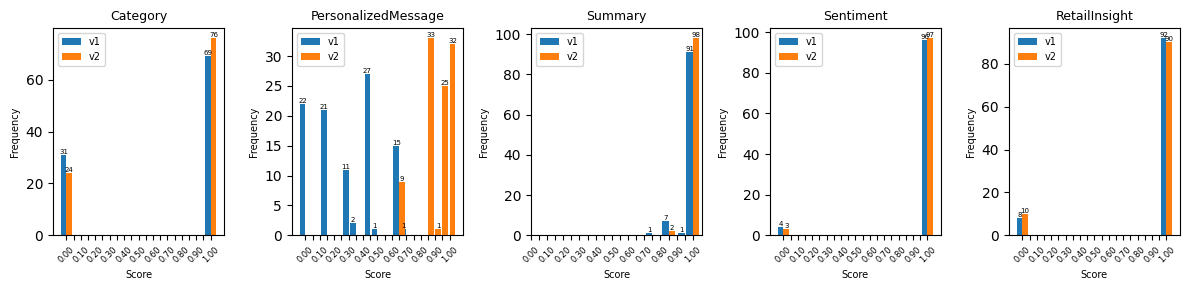

In [ ]:
# Comparison of scores V1 vs V2
plot_evaluation_comparison_histograms(zero_shot_v1_evaluations, zero_shot_v2_evaluations)

**Observation**
* 24 reviews with incorrect Category values comparing to inferred by LLM judge, an improvement from V1 with 31 incorrect Category values.  
* Personalized message shows the most significant improvement. Even without considering the penality for company name inclusion for V1, V2 still shows better quality for personalized message. 22 personalized message scored 0.0 from V1 while lowest score from V2 is 0.7. <br>
    * The following example shows clear improvement for specific issues and follow-ups in V2:<br>
          Review 9686:<br>
          **Text**: _This shirt was a cute print, but it was too boxy and hit too short on the thigh. i considered having it taken in the waist but ultimately decided it wasn't worth paying the extra \$ on top of the $88_<br>
          **V1**: _We're sorry to hear that the fit of this blouse did not meet your expectations. A team member will reach out to you to assist further._<br>
          **V2**: _We apologize for the fit issues you experienced with your blouse, and thank you for sharing your feedback with ChicStyle. Our team will review your comments to improve future fit and sizing; please contact us if you need further assistance._<br>

* Sentiment slightly improved from V1 to V2. RetailInsigh.Urgency score slightly declined.
* Overall v2 scores 0.906, an significant improvement from 0.772 for v1.

#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?

  * Place examples after instructions but before the final task.
  * Keep 3–5 examples max (more = diminishing returns)
  * Examples are what make the model apply them consistently, especially for tricky tradeoffs like:
      * Fit vs Quality
      * Primary vs Secondary issue
      * Overstatement vs factual tone
      * Mixed sentiment balance
  * Outputs must be perfect (judge-1.0 quality)
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
  * Add specific rule sections for each of the five fields in subject. (see V2 prompt below)
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?
  * See end of **Technique 2** for comparision V2 versus V1

#####Few-shot prompt V1

In [ ]:
# Based on zero-shot prompt, added
# * hints to better define categories
# * examples of different ratings to demo expected results
few_shot_prompt_template_v1 = """You are an AI assistant for analyzing customer reviews in a women's e-commerce clothing platform.

Given the following review data, extract structured insights.

---------------------
INPUT:
Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}
---------------------

FEW-SHOT EXAMPLES:

Example 1:
Input:
Clothing ID: 12345
Review Title: "Too small"
Review Text: "The dress is beautiful but runs very small and tight."
Rating: 2
Recommended: 0
Division: General
Department: Dresses
ClassName: Dresses

Output:
{{
  "Category": "Fit",
  "Sentiment": "Negative",
  "Summary": "Customer likes the dress design but reports it runs too small and tight, making it unsuitable in fit.",
  "PersonalizedMessage": "We’re sorry to hear about the sizing issue. A team member will reach out to assist you shortly.",
  "RetailInsight": {{
    "ClothingID": "12345",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "High"
  }}
}}

---------------------

Example 2:
Input:
Clothing ID: 67890
Review Title: "Love it!"
Review Text: "The fabric is soft and high quality. Fits perfectly and looks great."
Rating: 5
Recommended: 1
Division: General
Department: Tops
Class: Blouses

Output:
{{
  "Category": "Quality",
  "Sentiment": "Positive",
  "Summary": "Customer is highly satisfied with the soft fabric, quality, and perfect fit of the blouse.",
  "PersonalizedMessage": "Thank you for your wonderful feedback! We’re thrilled you love the product.",
  "RetailInsight": {{
    "ClothingID": "67890",
    "Division": "General",
    "Department": "Tops",
    "ClassName": "Blouses",
    "Urgency": "Low"
  }}
}}

---------------------

Example 3:
Input:
Clothing ID: 54321
Review Title: "Late delivery"
Review Text: "The dress arrived almost two weeks late but the product itself is fine."
Rating: 3
Recommended: 1
Division: General
Department: Dresses
Class: Dresses

Output:
{{
  "Category": "Delivery",
  "Sentiment": "Neutral",
  "Summary": "Customer experienced significant delivery delay but is satisfied with the product quality.",
  "PersonalizedMessage": "Thank you for your feedback. We apologize for the delay and appreciate your patience.",
  "RetailInsight": {{
    "ClothingID": "54321",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "Medium"
  }}
}}

---------------------

TASK:

Now analyze the following input:

1. Category
Fit | Quality | Delivery | Price | Other

2. Sentiment
Positive | Negative | Neutral

3. Summary
Include product + issue + product/service type

4. Personalized Message
Positive → thank user
Neutral → acknowledge
Negative → apologize + follow-up promise

5. Retail Insight
Include Division, Department, ClassName and urgency:
- High → serious complaint
- Medium → delays/repeated issues
- Low → minor issues or positive feedback

---------------------

OUTPUT FORMAT (STRICT JSON ONLY):

{{
  "Category": "...",
  "Sentiment": "...",
  "Summary": "...",
  "PersonalizedMessage": "...",
  "RetailInsight": {{
    "ClothingID": "...",
    "Division": "...",
    "Department": "...",
    "ClassName": "...",
    "Urgency": "High | Medium | Low"
  }}
}}"""

few_shot_prompt_v1 = ChatPromptTemplate.from_template(few_shot_prompt_template_v1)

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with few-shot prompt V1"):
    df_few_shot_result_v1 = review_processor.process_df_with_progress(df_sampled, few_shot_prompt_v1, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with few-shot prompt V1 took 187.810975 seconds


In [ ]:
df_few_shot_result_v1[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,Customer finds the classic white blouse flatte...,Thank you for your wonderful feedback! We’re g...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,Customer finds the jacket adorable and of nice...,Thank you for your helpful feedback! We're gla...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,"Customer is very pleased with the dress, highl...",Thank you for your wonderful feedback! We’re t...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,Customer received a sweater vest that was much...,We’re very sorry for the sizing and labeling i...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Negative,Customer loves the blouse's appearance but rep...,We’re very sorry to hear about the quality iss...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Neutral,Customer is attracted to the vest's design and...,Thank you for your feedback. We appreciate you...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Quality,Positive,Customer is very pleased with the blouse's sof...,Thank you for your wonderful feedback! We’re t...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,Customer found the cotton blouse's ruching des...,We’re sorry to hear that the fit and design di...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,Customer is pleased with the top's stretch and...,Thank you for your wonderful feedback! We’re g...,Low


In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from few-shot prompt V1"):
    few_shot_v1_evaluations = evaluate_prediction(df_few_shot_result_v1, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.7795999999999996]
average score: 0.7795999999999996
Evaluating result from few-shot prompt V1 took 571.421820 seconds


In [ ]:
# save the result dataframe
path_few_shot_result_v1 = path.join(project_root,'GenAIReviewCategorization','few_shot_result_v1.tsv')
df_few_shot_result_v1.to_csv(path_few_shot_result_v1, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load saved df_few_shot_result_v1
# df_few_shot_result_v1 = pd.read_csv(path_few_shot_result_v1, sep="\t")

# Save few_shot_v1_evaluations to json file
path_few_shot_v1_evaluations = path.join(project_root,'GenAIReviewCategorization','few_shot_v1_evaluations.json')
with open(path_few_shot_v1_evaluations, "w") as f:
    json.dump(few_shot_v1_evaluations, f, indent=4)
#Load back
#with open(path_few_shot_v1_evaluations, "r") as f:
#    few_shot_v1_evaluations = json.load(f)

In [ ]:
# retreive interesting exampes of sample scores and scoring reasons
example_scores_reasons_few_shot_v1 = list(filter(
    lambda x: (
        x['scores']['Category'] <1 or x['scores']['PersonalizedMessage']<=0.7
    ),
    few_shot_v1_evaluations[0]['details']
))

In [ ]:
create_evaluation_example_df(example_scores_reasons_few_shot_v1, df_few_shot_result_v1)

\
                                               Review   
0   This shirt is the perfect go-to; classic white...   
1   I need to remember that this brand runs small....   
2   This is a great dress that looks better in rea...   
3   I think i received a mislabeled vest?? when i ...   
4   I love this blouse, i've received so many comp...   
..                                                ...   
95  Just got this vest in my store yesterday and i...   
96  I'm normally a size small, but the store only ...   
97  I ordered this top because it was 100 percent ...   
98  Upon opening this top, i thought for sure it w...   
99  Nice t-shirt. the print is very nice and the f...   

                                                       Category  \
                                 Title original_index predicted   
0                         Great staple           2613       Fit   
1                     Adorable jacket!           9111       Fit   
2   Many compliments about this dress!          17741       Fit   
3                     Mini version????          10275       Fit   
4              Beautiful, poor quality          19764   Quality   
..                                 ...            ...       ...   
95                           Cool vest          14642       Fit   
96                 So soft and amazing           5653   Quality   
97                            Cute top           2264       Fit   
98                       Beautiful top           7285       Fit   
99                       Very feminine          22310   Quality   

                                                             \
                                               reason score   
0   Predicted category 'Fit' matches the inferred ...   1.0   
1   Predicted category 'Fit' matches the inferred ...   1.0   
2   The main praise is for the material quality, c...   0.0   
3   Predicted category 'Fit' matches the inferred ...   1.0   
4   Predicted category 'Quality' matches the infer...   1.0   
..                                                ...   ...   
95  Predicted category 'Fit' matches the inferred ...   1.0   
96  Score 0.0: The main focus is on how the blouse...   0.0   
97  Predicted category 'Fit' matches the inferred ...   1.0   
98  Predicted category 'Fit' matches the inferred ...   1.0   
99  Predicted category 'Quality' matches the infer...   1.0   

                                  PersonalizedMessage  \
                                            predicted   
0   Thank you for your wonderful feedback! We’re g...   
1   Thank you for your helpful feedback! We're gla...   
2   Thank you for your wonderful feedback! We’re t...   
3   We’re very sorry for the sizing and labeling i...   
4   We’re very sorry to hear about the quality iss...   
..                                                ...   
95  Thank you for your feedback. We appreciate you...   
96  Thank you for your wonderful feedback! We’re t...   
97  We’re sorry to hear that the fit and design di...   
98  Thank you for your wonderful feedback! We’re g...   
99  Thank you for your wonderful feedback! We’re g...   

                                                            Sentiment  \
                                               reason score predicted   
0   The message is positive and directionally appr...  0.15  Positive   
1   Message does not include 'ChicStyle' (0), but ...  0.65  Positive   
2   The message thanks the customer and expresses ...  0.45  Positive   
3   Score is 0.0 because the message does not ment...  0.00  Negative   
4   Message is polite, apologizes, and offers a ne...  0.45  Negative   
..                                                ...   ...       ...   
95  Message is generic but directionally appropria...  0.15   Neutral   
96  Score 0.15: The message is positive and thanks...  0.15  Positive   
97  The message is directionally appropriate (refe...  0.15  Negative   
98  Message thanks the customer and references the...  0.45  Positive   
99 

**Observation**

* 22 reviews receive 0.0 score for Category predictions. LLM judge  correctly scored with proper reason.

  For example:
  * For review 18514, Valid category 'Other', but incorrect classification. Expected 'Fit'.
  * For review 18468, Valid category 'Fit', but incorrect classification. Expected 'Quality'.
* Personalized messages receive 0.7 score for missing company name.
* 98 personalized messages received 0.7 or less scores due to missing company name and lack actions.

#####Few-shot prompt v2
* Explicit schema contract (field-level constraints)
* Label definitions (decision rules per category/sentiment)
* Error handling rules
* Stronger JSON schema consistency
* Rationale (optional hidden step for consistency, not output)
* Edge-case handling instructions

In [ ]:
# Based on few-shot prompt v1, added
# * hints to better define categories

few_shot_prompt_template_v2 = """
You are an expert AI system for analyzing customer reviews for ChicStyle, a women's fashion e-commerce platform.

You MUST strictly follow all instructions and output format requirements.

====================================================
INPUT DATA
====================================================

Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}

====================================================
TASK OVERVIEW
====================================================

Extract structured insights for:

1. Category classification (single label)
2. Sentiment classification
3. Concise summary
4. Personalized customer response
5. Retail operational insight

====================================================
CATEGORY DEFINITIONS (MUTUALLY EXCLUSIVE)
====================================================

Select EXACTLY ONE category:

- Delivery → shipping delays, late arrival, logistics issues, packaging problems, returns, customer service
- Fit → sizing issues, tight/loose fit, comfort, runs small/large
- Quality → fabric, material, stitching, durability, defects
- Price → cost, value for money, affordability, “overpriced” or “worth it”
- Other → anything not clearly fitting above

STRICT PRIORITY RULES (apply in order):

1. Delivery overrides ALL categories IF:
   - Shipping delay or logistics issue is mentioned as a complaint (even if product is good)

2. Fit overrides Quality IF:
   - Any sizing or fit issue is mentioned

3. Quality applies IF:
   - Product material or craftsmanship is the main concern WITHOUT fit issues

4. If multiple issues exist:
   - Select the PRIMARY cause of dissatisfaction (not secondary comments)

5. If no clear issue:
   - Use Other

====================================================
SENTIMENT RULES
====================================================

Classify overall sentiment:

- Positive → clear satisfaction, praise, recommendation
- Negative → complaint, dissatisfaction, frustration
- Neutral → mixed feedback OR weak/no emotional signal

DECISION RULES:

1. Strong negative language → Negative (regardless of rating)
2. Strong positive language → Positive
3. Mixed sentiment:
   - If complaint dominates → Negative
   - If praise dominates → Positive
   - Otherwise → Neutral

RATING-BASED ADJUSTMENTS:

- Rating ≤ 2 → default to Negative unless clearly contradictory
- Rating = 3 → likely Neutral unless strong sentiment present
- Rating ≥ 4 → default to Positive if language supports it

RECOMMENDED FLAG:

- Recommended = 0 → bias toward Negative
- Recommended = 1 → bias toward Positive

FINAL RULE:
- Text sentiment ALWAYS overrides rating if clearly expressed

====================================================
SUMMARY RULES
====================================================

- Maximum 2 sentences

STRUCTURE:

Sentence 1:
→ Product + key experience (positive or negative)

Sentence 2 (optional):
→ Specific issue OR additional context (fit, quality, delivery, etc.)

REQUIREMENTS:

- Always mention product type (e.g., dress, blouse)
- Include key issue OR praise AND context

STYLE RULES:

- Concise, factual, non-repetitive
- No speculation or assumptions
- Avoid generic phrases like "customer is happy"

====================================================
PERSONALIZED MESSAGE RULES
====================================================

MUST:
- Include the brand name: "ChicStyle"
- Reference the specific issue or praise
- Sound natural and human (not robotic)

TONE:
- Positive → Thank + appreciation
- Neutral → Acknowledge + light reassurance
- Negative → Apologize + clear next step (refund, exchange, support)

DO:
- Offer resolution when Negative
- Show appreciation when Positive

DO NOT:
- Overpromise
- Use vague generic responses

====================================================
URGENCY RULES
====================================================

Assign urgency based on BUSINESS IMPACT:

HIGH:
- Defective/damaged product
- Wrong item received
- Severe fit issue (unwearable)
- Strong dissatisfaction or frustration
- Explicit return/refund intent

MEDIUM:
- Delivery delays
- Noticeable but not critical issues
- Mixed sentiment with some dissatisfaction

LOW:
- Positive feedback
- Minor concerns or suggestions
- No actionable issue

ESCALATION RULES:

1. Negative + product unusable → HIGH
2. Negative + inconvenience only → MEDIUM
3. Neutral + issue present → MEDIUM
4. Positive → LOW

FINAL RULE:
- Urgency reflects how urgently the business should act, NOT just sentiment

====================================================
RETAIL INSIGHT RULES
====================================================

- MUST include all fields exactly
- NEVER modify or infer missing metadata
- ClothingID must match input exactly

====================================================
FEW-SHOT EXAMPLES
====================================================

Example 1:

Input:
Clothing ID: 12345
Review Title: "Too small"
Review Text: "The dress is beautiful but runs very small and tight."
Rating: 2
Recommended: 0
Division: General
Department: Dresses
ClassName: Dresses

Output:
{{
  "Category": "Fit",
  "Sentiment": "Negative",
  "Summary": "Customer reports the dress runs very small and feels tight despite liking the design.",
  "PersonalizedMessage": "We’re sorry the sizing didn’t work as expected. ChicStyle will gladly assist you with an exchange or return.",
  "RetailInsight": {{
    "ClothingID": "12345",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "High"
  }}
}}

----------------------------------------------------

Example 2:

Input:
Clothing ID: 67890
Review Title: "Love it!"
Review Text: "The fabric is soft and high quality. Fits perfectly and looks great."
Rating: 5
Recommended: 1
Division: General
Department: Tops
ClassName: Blouses

Output:
{{
  "Category": "Quality",
  "Sentiment": "Positive",
  "Summary": "Customer is highly satisfied with the blouse’s soft fabric, quality, and perfect fit.",
  "PersonalizedMessage": "Thank you for your wonderful feedback! ChicStyle is thrilled that you love the quality and fit.",
  "RetailInsight": {{
    "ClothingID": "67890",
    "Division": "General",
    "Department": "Tops",
    "ClassName": "Blouses",
    "Urgency": "Low"
  }}
}}

----------------------------------------------------

Example 3:

Input:
Clothing ID: 54321
Review Title: "Late delivery"
Review Text: "The dress arrived almost two weeks late but the product itself is fine."
Rating: 3
Recommended: 1
Division: General
Department: Dresses
ClassName: Dresses

Output:
{{
  "Category": "Delivery",
  "Sentiment": "Neutral",
  "Summary": "Customer experienced a significant delivery delay but is satisfied with the dress.",
  "PersonalizedMessage": "Thank you for your feedback. ChicStyle sincerely apologizes for the delay and appreciates your patience.",
  "RetailInsight": {{
    "ClothingID": "54321",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "Medium"
  }}
}}

====================================================
CRITICAL OUTPUT RULES
====================================================

- Output MUST be valid JSON only
- Do NOT include explanations or markdown
- Do NOT add extra keys
- ALL fields are required
- Summary ≤ 2 sentences
- Use exact key names
- Use consistent spelling: ChicStyle

====================================================
FINAL TASK
====================================================

Now analyze the input and generate the structured JSON output exactly as specified.

"""

few_shot_prompt_v2 = ChatPromptTemplate.from_template(few_shot_prompt_template_v2)

###### V2 Prompt Improvements from V1

##### 1. Category Classification
* Added **strict priority rules** (Delivery > Fit > Quality > Price > Other)
* Resolves multi-issue conflicts deterministically
* Focuses on **primary cause of dissatisfaction**

    Example:
    Review: “Dress fits badly and arrived late.”

    * V1 → Fit
    * Improved V2 → Delivery (delivery overrides)

##### 2. Sentiment Classification
* Introduced **multi-signal logic**:
  * Text sentiment (primary)
  * Rating (support)
  * Recommended flag (bias)
* Handles **mixed sentiment explicitly**

    Example:
    Review: “Looks great but runs small.” (Rating: 4)

    * V1 → Positive
    * Improved V2 → Neutral (mixed sentiment)

##### 3. Summary Generation

* Enforced **structured format**:

  * Sentence 1: product + experience
  * Sentence 2: issue/context
* Limited to **≤ 2 sentences**
* Requires product + issue + context

    Example:
    Review: “Soft fabric but poor stitching.”

    * V1 → “Customer has mixed feelings.”
    * Improved V2 → “Customer likes the top’s soft fabric but reports poor stitching quality.”

##### 4. Urgency Classification
* Based on **business impact**, not just sentiment
* Added **clear escalation rules**

    Example:
    Review: “The zipper broke on first use.”

    * V1 → Medium
    * Improved V2 → High (product unusable)

##### 5. Multi-Issue Handling

* Explicit rule: **select primary issue only**

    Example:
    Review: “Fabric is great but sizing is off.”

    * V1 → Quality
    * Improved V2 → Fit (fit takes priority)

##### 6. Edge Case Handling

* Handles:

  * Mixed sentiment
  * Weak signals
  * Rating vs text conflicts

    Example:
    Review: “It’s okay.” (Rating: 5)

    * V1 → Positive
    * Improved V2 → Neutral (weak sentiment)

##### 7. Consistency & Determinism

* Replaced loose interpretation with **rule-based decisions**
* Added priority + tie-breakers

  Example:
  Review: “Runs large and feels cheap.”

  * V1 → Inconsistent (Fit or Quality)
  * Improved V2 → Fit (rule enforced)

##### 8. Hallucination Reduction

* Explicit constraints:

  * No speculation
  * No adding unsupported details

  Example:
  Review: “Nice dress.”

  * V1 → “Fits well and high quality” (hallucinated)
  * Improved V2 → “Customer expresses general satisfaction with the dress.”

##### 9. Better Evaluation Alignment

* Outputs structured for **LLM judge compatibility**
* Enables consistent scoring and benchmarking

  Example:

  * V1 summary → vague → hard to score
  * Improved V2 summary → structured → easy to evaluate components (product, issue, context)

##### Result

* Higher accuracy
* More consistent outputs
* Better business relevance
* Reduced hallucination
* Production-ready prompt design


###### Review processing with V2 prompt and evaluation

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with few-shot prompt V2"):
    df_few_shot_result_v2 = review_processor.process_df_with_progress(df_sampled, few_shot_prompt_v2, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with few-shot prompt V2 took 297.984486 seconds


In [ ]:
df_few_shot_result_v2[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,Customer finds the blouse to be a classic stap...,Thank you for sharing your experience! ChicSty...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,Customer finds the jacket adorable and appreci...,Thank you for sharing your experience! ChicSty...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,Customer is very pleased with the dress’s flat...,Thank you for sharing your experience! ChicSty...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,Customer received a sweater vest that was much...,We’re very sorry the sweater vest did not fit ...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Negative,Customer loves the blouse’s appearance and rec...,We’re very sorry for the fabric issues you exp...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Positive,Customer finds the vest visually striking and ...,Thank you for your feedback! ChicStyle is glad...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Fit,Positive,Customer finds the blouse fits well as an over...,Thank you for sharing your experience! ChicSty...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,Customer found the blouse’s ruching created an...,We’re sorry the fit of this blouse was disappo...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,Customer is pleased with the knit top’s stretc...,Thank you for sharing your experience! ChicSty...,Low


In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from few-shot prompt V2"):
    few_shot_v2_evaluations = evaluate_prediction(df_few_shot_result_v2, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.9291999999999995]
average score: 0.9291999999999995
Evaluating result from few-shot prompt V2 took 563.045745 seconds


In [ ]:
# save the result dataframe
path_few_shot_result_v2= path.join(project_root,'GenAIReviewCategorization','few_shot_result_v2.tsv')
df_few_shot_result_v2.to_csv(path_few_shot_result_v2, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load saved df_few_shot_result_v2
# df_few_shot_result_v2 = pd.read_csv(path_few_shot_result_v2, sep="\t")

# Save few_shot_v2_evaluations to json file
path_few_shot_v2_evaluations = path.join(project_root,'GenAIReviewCategorization','few_shot_v2_evaluations.json')
with open(path_few_shot_v2_evaluations, "w") as f:
    json.dump(few_shot_v2_evaluations, f, indent=4)
#Load back
#with open(path_few_shot_v2_evaluations, "r") as f:
#    few_shot_v2_evaluations = json.load(f)

In [ ]:
# retreive interesting exampes of sample scores and scoring reasons
example_scores_reasons_few_shot_v2 = list(filter(
    lambda x: (x['scores']['Category'] <1),
    few_shot_v2_evaluations[0]['details']
))

In [ ]:
create_evaluation_example_df(example_scores_reasons_few_shot_v2, df_few_shot_result_v2)

\
                                               Review   
0   This is a great dress that looks better in rea...   
1   This is a great dress that can be dressed up o...   
2   This "little" dress is extremely cute and very...   
3   This is just okay for me. the top is soft and ...   
4   Love this dress!!! must try on to see how cute...   
5   This dress is a beautiful, classic dress that ...   
6   I was so looking forward to an awesome maxi dr...   
7   Fits loose good material. will buy in other co...   
8   I love the style and the look of this sweater....   
9   Very nice sweater, surprisingly just as pictur...   
10  Saw this on line and bought right away! perfec...   
11  The top is really cute, but it's see through a...   
12  Love to just throw on this shirt with whatever...   
13  You won't break the bank with this cute tee. l...   
14  I bought these on a whim, patterned bottoms ar...   
15  This dress is not form fitting and some might ...   
16  I bought this top and it ran huge, i had to ge...   
17  I wasn't sure about this shirt at first glance...   
18  I saw this online, visited my local retailer, ...   
19  Great, rather heavyweight, long cardi. i purch...   
20  I'm normally a size small, but the store only ...   

                                                       Category  \
                                 Title original_index predicted   
0   Many compliments about this dress!          17741       Fit   
1         This dress is very versitile          18514     Other   
2         Styish, cute and comfortable           4272     Other   
3                                  Meh          11490       Fit   
4                                  NaN          11675     Other   
5                 Gorgeous black dress          10659     Other   
6           See through beach cover up           9757       Fit   
7                                  NaN          21115       Fit   
8   Gorgeous style but very very itchy           8820       Fit   
9          Very nice, just as pictured          22857       Fit   
10           Super cute summer romper!          10960       Fit   
11      Cute top but not for the price           3382   Quality   
12              Easy shirt to throw on          14819     Other   
13                   Decent little tee          19844       Fit   
14                       Great pattern           1628       Fit   
15                        Summer dress           6293       Fit   
16   Cute top....but shrinks horribly!           2128       Fit   
17                         Great basic           9038       Fit   
18            Beautiful shade of blue!          20981       Fit   
19             Beautiful shade of blue           6351       Fit   
20                 So soft and amazing           5653       Fit   

                                                             \
                                               reason score   
0   Score 0.0: The inferred category is 'Quality' ...   0.0   
1   Predicted category is 'Other', but the main pr...   0.0   
2   Score is 0.0 because the inferred category is ...   0.0   
3   Score 0.0: The main issues are with the neckli...   0.0   
4   Predicted 'Other' but the review specifically ...   0.0   
5   Score 0.0: Predicted category is 'Other', but ...   0.0   
6   Score 0.0. The main complaint is about the dre...   0.0   
7   Score 0.0: The main praise is for the good mat...   0.0   
8   Score 0.0. The main complaint is about the swe...   0.0   
9   Score is 0.0 because the inferred category is ...   0.0   
10  Score 0.0: Predicted 'Fit' but inferred 'Quali...   0.0   
11  Score 0.0: The main complaint is about the pro...   0.0   
12  Score 0.0: Predicted 'Other' but inferred 'Fit...   0.0   
13  Score 0.0: Predicted 'Fit' but the main reason...   0.0   
14  Score 0.0: Predicted 'Fit' but the main praise...   0.0   
15  Score is 0.0 because the inferred category is ...   0.0   
16  Score is 0.0 because the inferred category is ...   0.0   
17  

In [ ]:
few_shot_v2_evalation_example = create_evaluation_example_df(example_scores_reasons_few_shot_v2, df_few_shot_result_v2)
few_shot_v1_evalation_example = create_evaluation_example_df(example_scores_reasons_few_shot_v1, df_few_shot_result_v1)
show_personalized_messages_with_largest_improved_score(few_shot_v1_evalation_example, few_shot_v2_evalation_example)

,original_index,delta,PersonalizedMessage_predicted_v2,PersonalizedMessage_score_v2,PersonalizedMessage_predicted_v1,PersonalizedMessage_score_v1
16,2128,1.00,We’re very sorry for your experience with the ...,1.00,We’re very sorry for the experience with shrin...,0.00
6,9757,0.95,We’re sorry the fit and design of this dress d...,0.95,We’re sorry to hear about your experience with...,0.00
1,18514,0.85,Thank you for sharing your positive experience...,1.00,Thank you for your wonderful feedback! We’re t...,0.15
10,10960,0.80,Thank you for your wonderful feedback! ChicSty...,0.95,Thank you for your wonderful feedback! We’re t...,0.15
11,3382,0.75,We’re sorry the blouse’s material and quality ...,0.90,We’re sorry the quality did not meet your expe...,0.15


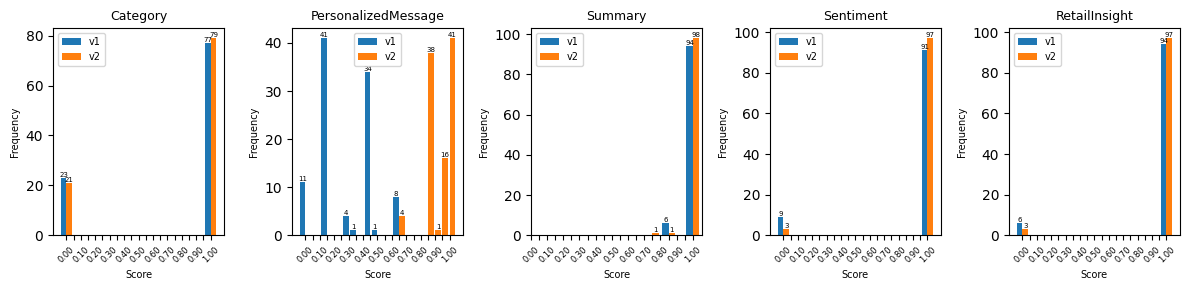

In [ ]:
# Comparison of scores V1 vs V2
plot_evaluation_comparison_histograms(few_shot_v1_evaluations, few_shot_v2_evaluations)

**Observation**
* 21 reviews with incorrect Category values comparing to inferred by LLM judge, a slight improvement from V1 with 23 incorrect Category values.  
* Personalized message shows the most significant improvement. Even without considering the penality for company name inclusion for V1, V2 still shows better quality for personalized message. 11 personalized message scored 0.0 from V1 while lowest score from V2 is 0.7. <br>
    * The following example shows clear improvement for identifying both sizing and shrinkage issues and follow-up options in V2:<br>
          Review 2128:<br>
          **Text**: _I bought this top and it ran huge, i had to get an extra small. well then i wash it according to the instructions and it shrunk horribly! like its so small now my 3 yr old could probably wear it! i'm so sad, i really liked this top....but for it to shrink after one wear is not acceptable._<br>
          **V1**: _We’re very sorry for the experience with shrinkage. A team member will reach out to help resolve this issue._<br>
          **V2**: _We’re very sorry for your experience with the sizing and shrinkage. ChicStyle will assist you with a return or exchange to resolve this issue promptly._<br>

* Summary, Sentiment and Urgency all improved from V1 to V2.
* V2 score 0.929 is a significant improvement from 0.780 for V1. The above histogram comparision confirms the improvement in all 5 predictions/classifications. PersonalizedMessage receives the most significant improvement.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?

    * Perform structured internal reasoning before answering.
    - Think step-by-step internally.
    - Do NOT output your reasoning.
    - Do NOT include explanations, notes, or intermediate steps.
    - Output ONLY the final structured JSON.
        
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?

    * Combine them by separating the prompt into hidden reasoning, field rules, and strict output.
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

    * Yes. By adding consistent & details rules for each field. We are able to impreove scoring in all fields.

#####Chain-of-Thought prompt V1

In [ ]:
CoT_prompt_template_v1 = """You are an AI assistant for analyzing customer reviews in a women's e-commerce clothing platform.

You MUST follow a structured reasoning process before producing the final JSON output.

DO NOT output reasoning. Only output the final JSON.

====================================================
INPUT
====================================================
Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}

====================================================
CHAIN-OF-THOUGHT INSTRUCTIONS (DO NOT OUTPUT)
====================================================

Before answering, internally perform the following steps:

Step 1: Understand the review
- Identify what product is being discussed
- Identify key issues or praise points

Step 2: Classify Category
- Fit → size, comfort, tight/loose
- Quality → fabric, stitching, material
- Delivery → shipping, returns, logistics
- Price → cost/value concerns
- Other → none of the above

Step 3: Determine Sentiment
- Positive → praise or satisfaction
- Negative → complaints or dissatisfaction
- Neutral → mixed or factual tone

Use Rating + Recommended + text jointly.

Step 4: Extract Summary
- Mention product
- Mention main issue or praise
- Mention whether it is product or service related

Step 5: Generate Personalized Message
- Positive → thank the customer warmly
- Neutral → acknowledge politely
- Negative → apologize and promise follow-up

Step 6: Determine Retail Insight & Urgency
- High → severe issue (defect, wrong item, strong dissatisfaction)
- Medium → delivery delay or repeated inconvenience
- Low → minor issue or positive feedback

====================================================
Chain-of-Thoughts EXAMPLES
====================================================

Example 1:
Input:
Clothing ID: 12345
Review Title: "Too small"
Review Text: "The dress is beautiful but runs very small and tight."
Rating: 2
Recommended: 0
Division: General
Department: Dresses
ClassName: Dresses

Output:
{{
  "Category": "Fit",
  "Sentiment": "Negative",
  "Summary": "Customer likes the dress design but reports it runs very small and tight, making it unsuitable in fit.",
  "PersonalizedMessage": "We’re sorry to hear about the sizing issue. A team member will reach out to assist you shortly.",
  "RetailInsight": {{
    "ClothingID": "12345",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "High"
  }}
}}

----------------------------------------------------

Example 2:
Input:
Clothing ID: 67890
Review Title: "Love it!"
Review Text: "The fabric is soft and high quality. Fits perfectly and looks great."
Rating: 5
Recommended: 1
Division: General
Department: Tops
Class: Blouses

Output:
{{
  "Category": "Quality",
  "Sentiment": "Positive",
  "Summary": "Customer is highly satisfied with the soft fabric, quality, and perfect fit of the blouse.",
  "PersonalizedMessage": "Thank you for your wonderful feedback! We’re thrilled you love the product.",
  "RetailInsight": {{
    "ClothingID": "67890",
    "Division": "General",
    "Department": "Tops",
    "ClassName": "Blouses",
    "Urgency": "Low"
  }}
}}

----------------------------------------------------

Example 3:
Input:
Clothing ID: 54321
Review Title: "Late delivery"
Review Text: "The dress arrived almost two weeks late but the product itself is fine."
Rating: 3
Recommended: 1
Division: General
Department: Dresses
Class: Dresses

Output:
{{
  "Category": "Delivery",
  "Sentiment": "Neutral",
  "Summary": "Customer experienced significant delivery delay but is satisfied with the product quality.",
  "PersonalizedMessage": "Thank you for your feedback. We apologize for the delay and appreciate your patience.",
  "RetailInsight": {{
    "ClothingID": "54321",
    "Division": "General",
    "Department": "Dresses",
    "ClassName": "Dresses",
    "Urgency": "Medium"
  }}
}}

====================================================
FINAL TASK
====================================================

Now analyze the input using the above reasoning steps.

IMPORTANT RULES:
- Do NOT output intermediate reasoning
- Output ONLY valid JSON
- Do NOT add extra keys
- Always include all required fields
"""

CoT_prompt_v1 = ChatPromptTemplate.from_template(CoT_prompt_template_v1)

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with CoT prompt V1"):
    df_CoT_result_v1 = review_processor.process_df_with_progress(df_sampled, CoT_prompt_v1, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with CoT prompt V1 took 223.765338 seconds


In [ ]:
df_CoT_result_v1[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,Customer finds this classic white blouse to be...,Thank you for your wonderful feedback! We’re g...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,Customer finds the jacket adorable and of nice...,Thank you for your helpful feedback! We're gla...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,"Customer is very pleased with the dress, highl...",Thank you for your wonderful feedback! We’re d...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,Customer received a vest that was much shorter...,We’re sorry to hear about the sizing and produ...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Negative,Customer loves the blouse's appearance and rec...,We’re very sorry to hear about the fabric qual...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Neutral,Customer finds the vest visually appealing wit...,Thank you for your feedback! We appreciate you...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Quality,Positive,Customer is very pleased with the blouse's sof...,Thank you for your wonderful feedback! We’re d...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,Customer found the cotton blouse's ruching des...,We’re sorry to hear that the fit and design di...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,Customer finds the top beautiful and appreciat...,Thank you for your lovely feedback! We're glad...,Low


In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from CoT prompt V1"):
    CoT_v1_evaluations = evaluate_prediction(df_CoT_result_v1, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.7837]
average score: 0.7837
Evaluating result from CoT prompt V1 took 598.809905 seconds


In [ ]:
# save the result dataframe
path_CoT_result_v1 = path.join(project_root,'GenAIReviewCategorization','CoT_result_v1.tsv')
df_CoT_result_v1.to_csv(path_CoT_result_v1, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load saved df_CoT_result_v1
# df_CoT_result_v1 = pd.read_csv(path_CoT_result_v1, sep="\t")

# Save CoT_v1_evaluations to json file
path_CoT_v1_evaluations = path.join(project_root,'GenAIReviewCategorization','CoT_v1_evaluations.json')
with open(path_CoT_v1_evaluations, "w") as f:
    json.dump(CoT_v1_evaluations, f, indent=4)
#Load back
#with open(path_CoT_v1_evaluations, "r") as f:
#    CoT_v1_evaluations = json.load(f)

In [ ]:
# retreive interesting exampes of sample scores and scoring reasons
example_scores_reasons_CoT_v1 = list(filter(
    lambda x: (
        x['scores']['Category']<1 or x['scores']['PersonalizedMessage']<1
    ),
    CoT_v1_evaluations[0]['details']
))


In [ ]:
create_evaluation_example_df(example_scores_reasons_CoT_v1, df_CoT_result_v1)

\
                                               Review   
0   This shirt is the perfect go-to; classic white...   
1   I need to remember that this brand runs small....   
2   This is a great dress that looks better in rea...   
3   I think i received a mislabeled vest?? when i ...   
4   I love this blouse, i've received so many comp...   
..                                                ...   
95  Just got this vest in my store yesterday and i...   
96  I'm normally a size small, but the store only ...   
97  I ordered this top because it was 100 percent ...   
98  Upon opening this top, i thought for sure it w...   
99  Nice t-shirt. the print is very nice and the f...   

                                                       Category  \
                                 Title original_index predicted   
0                         Great staple           2613       Fit   
1                     Adorable jacket!           9111       Fit   
2   Many compliments about this dress!          17741       Fit   
3                     Mini version????          10275       Fit   
4              Beautiful, poor quality          19764   Quality   
..                                 ...            ...       ...   
95                           Cool vest          14642       Fit   
96                 So soft and amazing           5653   Quality   
97                            Cute top           2264       Fit   
98                       Beautiful top           7285       Fit   
99                       Very feminine          22310   Quality   

                                                             \
                                               reason score   
0   Predicted category 'Fit' matches the inferred ...   1.0   
1   Predicted category 'Fit' matches the inferred ...   1.0   
2   Score is 0.0 because the inferred category is ...   0.0   
3   The predicted category 'Fit' exactly matches t...   1.0   
4   Predicted category 'Quality' matches the infer...   1.0   
..                                                ...   ...   
95  Predicted category 'Fit' exactly matches the i...   1.0   
96  Predicted category 'Quality' matches the infer...   1.0   
97  Predicted category 'Fit' matches the inferred ...   1.0   
98  Score 1.0: The main focus is on fit (stretchin...   1.0   
99  Predicted category 'Quality' matches the infer...   1.0   

                                  PersonalizedMessage  \
                                            predicted   
0   Thank you for your wonderful feedback! We’re g...   
1   Thank you for your helpful feedback! We're gla...   
2   Thank you for your wonderful feedback! We’re d...   
3   We’re sorry to hear about the sizing and produ...   
4   We’re very sorry to hear about the fabric qual...   
..                                                ...   
95  Thank you for your feedback! We appreciate you...   
96  Thank you for your wonderful feedback! We’re d...   
97  We’re sorry to hear that the fit and design di...   
98  Thank you for your lovely feedback! We're glad...   
99  Thank you for your lovely feedback! We're glad...   

                                                            Sentiment  \
                                               reason score predicted   
0   The message is positive and expresses apprecia...  0.15  Positive   
1   Message does not include 'ChicStyle' (0), is d...  0.15  Positive   
2   Score is 0.45: 0 for missing 'ChicStyle', 0.3 ...  0.45  Positive   
3   The message is polite, references the sizing a...  0.45  Negative   
4   The message apologizes and offers assistance, ...  0.50  Negative   
..                                                ...   ...       ...   
95  The message thanks the customer and references...  0.15   Neutral   
96  Message does not include 'ChicStyle' (0), but ...  0.15  Positive   
97  Message does not include 'ChicStyle' (0), but ...  0.45  Negative   
98  Score 0.15: The message is positive and thanks...  0.15  Positive   
99 

#####Chain-of-Thought promot V2

There are several issues with V1.

* CoT steps are too generic. (not decision-enforcing)
* Category/Sentiment rules are not conflict-resolving.
* No tie-break rules for ambiguous reviews.
* No structured rubrics for each of 5 the prediction fields.
* No error handling rules.

Address above issues in V2 to improve for accuracy, consistency, and ambiguity reduction.

In [ ]:
CoT_prompt_template_v2 = """
You are an expert AI system for analyzing customer reviews for ChicStyle, a women's fashion e-commerce platform.

You MUST perform structured internal reasoning BEFORE producing the final JSON output.

IMPORTANT:
- NEVER output reasoning
- ONLY output final JSON

====================================================
INPUT
====================================================

Clothing ID: {clothing_id}
Review Title: {title}
Review Text: {review}
Rating: {rating}
Recommended: {recommended}
Division: {division}
Department: {department}
ClassName: {class_name}

====================================================
GLOBAL DECISION PRIORITY (CRITICAL)
====================================================

When signals conflict, follow this strict priority:

1. Review Text (PRIMARY – overrides all)
2. Rating (supporting)
3. Recommended (weak signal)
4. Title (context only)

====================================================
INTERNAL REASONING PROCESS (DO NOT OUTPUT)
====================================================

Step 1: Identify PRIMARY SIGNAL
- What is the main issue or praise?
- Is it product-related or service-related?
- Ignore secondary comments unless dominant

----------------------------------------------------
Step 2: Category Classification (STRICT + JUDGE-ALIGNED)
----------------------------------------------------

Select EXACTLY ONE:

- Delivery → shipping delay, logistics, packaging, returns, customer service
- Fit → sizing, tight/loose, comfort, runs small/large
- Quality → fabric, material, stitching, durability, defects
- Price → cost, affordability, value perception
- Other → none of the above

----------------------------------------------------
STEP 2A: IDENTIFY PRIMARY DRIVER (MANDATORY)
----------------------------------------------------

Determine ONE dominant driver using explicit signals:

FIT SIGNALS (→ Category = Fit):
- runs small/large, tight/loose
- boxy, sack-like, clingy, oversized
- sleeve length, proportions, shape issues
- discomfort CAUSED BY sizing or fit
- phrases like: "fit like a sack", "too big", "too tight"

QUALITY SIGNALS (→ Category = Quality):
- fabric, material, softness, thickness
- see-through, thin, cheap, itchy (material-driven)
- stitching, construction, durability
- praise like: "well made", "good quality", "soft fabric"

CRITICAL DISAMBIGUATION RULE:
- "Comfort" due to fabric/material → Quality
- "Discomfort" due to sizing/shape → Fit
  (This rule is MANDATORY and overrides ambiguity)

OTHER SIGNALS (→ Category = Other):
- care/maintenance issues (dry clean only, hard to wash)
- impractical usage NOT caused by fit or material

----------------------------------------------------
STEP 2B: STRICT DECISION RULES
----------------------------------------------------

1. Delivery complaint → ALWAYS Delivery

2. If sizing/shape affects wearability → Fit

3. If fabric/material is the main issue → Quality

4. If care/maintenance is the main issue → Other

5. Mixed signals:
   - If fit makes item unwearable → Fit
   - If fabric defect makes item unusable → Quality

6. Praise cases:
   - Fabric/softness/construction → Quality
   - Fit/sizing/flattering → Fit

7. If unclear:
   → Choose the MOST explicit issue in text (DO NOT infer)

----------------------------------------------------
FINAL CHECK (MANDATORY)
----------------------------------------------------

[ ] Is this the MOST dominant issue (not secondary)?
[ ] Does it match what drives satisfaction/dissatisfaction?

If ANY fail → reclassify

----------------------------------------------------
PRIMARY ISSUE LOCK (CRITICAL)
----------------------------------------------------

After selecting Category, DEFINE:

PRIMARY ISSUE = the exact reason used to select Category

Examples:
- Category = Fit → PRIMARY ISSUE = sizing / shape / proportions
- Category = Quality → PRIMARY ISSUE = fabric / material / construction
- Category = Other → PRIMARY ISSUE = care / usability issue

IMPORTANT:
- PRIMARY ISSUE is FINAL
- DO NOT re-evaluate or change it in later steps

----------------------------------------------------
Step 3: Sentiment Classification (TEXT-FIRST + MULTI-SIGNAL)
----------------------------------------------------

Determine sentiment:

- Positive → clear satisfaction, praise, recommendation
- Negative → complaint, frustration, dissatisfaction
- Neutral → mixed OR weak/no strong emotion

DECISION RULES:

1. Strong emotional language → overrides rating
2. Mixed sentiment:
   - complaint dominates → Negative
   - praise dominates → Positive
   - otherwise → Neutral

SUPPORT SIGNALS:

- Rating ≤ 2 → bias Negative
- Rating = 3 → Neutral unless strong sentiment
- Rating ≥ 4 → bias Positive
- Recommended = 0 → supports Negative
- Recommended = 1 → supports Positive

FINAL RULE:
- Text sentiment ALWAYS wins if clear

----------------------------------------------------
STEP 4: SUMMARY (CATEGORY-LOCKED + SECONDARY ISSUE ALLOWED)
----------------------------------------------------

Generate EXACTLY 1–2 sentences.

RULE (CRITICAL):

- Summary MUST be derived ONLY from:
  → Category
  → PRIMARY ISSUE (from Step 2)

- DO NOT change the PRIMARY ISSUE
- A SECONDARY ISSUE may be included ONLY if it is explicitly stated in the review and does not conflict with the PRIMARY ISSUE

----------------------------------------
STRUCTURE
----------------------------------------

Sentence 1 (MANDATORY):
→ Product + overall experience + PRIMARY ISSUE

Sentence 2 (OPTIONAL):
→ Secondary issue, return/outcome, or added context

----------------------------------------
HARD CONSTRAINTS
----------------------------------------

1. PRIMARY ISSUE is mandatory and must match Category exactly:

- If Category = Fit:
  → PRIMARY ISSUE must describe sizing / shape / proportions / wearability due to fit

- If Category = Quality:
  → PRIMARY ISSUE must describe fabric / material / construction / defect

- If Category = Delivery:
  → PRIMARY ISSUE must describe shipping / return / logistics / customer service issue

- If Category = Price:
  → PRIMARY ISSUE must describe cost / value concern

- If Category = Other:
  → PRIMARY ISSUE must describe care / maintenance / other non-fit, non-quality, non-delivery, non-price issue

2. SECONDARY ISSUE is optional and allowed ONLY if:
- it is explicitly mentioned in the review
- it is not stronger than the PRIMARY ISSUE
- it does not replace or overshadow the PRIMARY ISSUE
- it is mentioned briefly as supporting context

3. If return, refund, or exchange is mentioned:
→ Prefer to include it in Sentence 2

----------------------------------------
FAIL-SAFE RULES
----------------------------------------

- The first issue mentioned in the summary MUST be the PRIMARY ISSUE
- Never let the SECONDARY ISSUE appear more important than the PRIMARY ISSUE
- If adding a SECONDARY ISSUE makes the summary ambiguous, omit it
- If mismatch with Category → REWRITE summary

----------------------------------------
EXAMPLES
----------------------------------------

Example A:
Category = Quality
Summary:
"The maxi dress was disappointing because the material was completely see-through and felt poorly designed. The customer also noted the oversized fit and returned it."

Example B:
Category = Fit
Summary:
"The top was not wearable because the fit was boxy and overly loose. The customer also mentioned the fabric was only average."

Example C:
Category = Other
Summary:
"The sweater was attractive but impractical because it required difficult care and maintenance. No major fit or fabric defect was described."

----------------------------------------------------
PRECISION & BALANCE RULES (HIGH-IMPACT FIX)
----------------------------------------------------

1. NO OVERSTATEMENT (CRITICAL)

- Do NOT escalate severity beyond the review text

Examples:
- If review says: "not great fit"
  → DO NOT say: "not wearable"

- If review implies inconvenience
  → DO NOT convert to failure

RULE:
→ Use equal or weaker language than the review, NEVER stronger

2. MIXED SENTIMENT BALANCE (MANDATORY)

If BOTH positive and negative points exist:

→ MUST include:
   - PRIMARY issue (aligned with Category)
   - ONE key positive aspect (brief)

Examples:
- "The dress had fit issues, though the color and design were appealing."
- "The top runs large, but the fabric feels soft and high quality."

DO NOT:
- Ignore strong positive signals
- Overweight negative if sentiment is mixed

3. CONCISENESS CONTROL

- Avoid repeating similar issues:
  "fit was oversized" better than "fit was loose and oversized and too big"

- Combine related attributes:
  "material quality" bettern than "material and fabric quality"

4. LANGUAGE CALIBRATION

Use calibrated wording:

| Review Language | Summary Language |
|----------------|----------------|
| "a bit large"  | "slightly large" |
| "too big"      | "runs large" |
| "not flattering" | "less flattering than expected" |
| "would return" | "was returned" |
| "might return" | "considered returning" |

5. SECONDARY ISSUE PRIORITY

If including a secondary issue:

- Prefer:
  1. Return / outcome
  2. Positive aspect (if mixed sentiment)
  3. Minor secondary flaw

6. SUMMARY FINAL SELF-CHECK (MANDATORY)

[ ] Any exaggerated wording vs original review?
[ ] If mixed sentiment → is ONE positive included?
[ ] Any repetition or redundant phrasing?
[ ] Is tone strictly factual (not emotional)?


----------------------------------------
SELF-CHECK
----------------------------------------

[ ] Is the PRIMARY ISSUE stated first?
[ ] Does the PRIMARY ISSUE match Category exactly?
[ ] Is any SECONDARY ISSUE clearly secondary?
[ ] If included, is the SECONDARY ISSUE explicit in the review?
[ ] If return/refund is mentioned, was it included when useful?

If ANY fail → REWRITE summary

----------------------------------------------------
Step 5: PersonalizedMessage (STRICT)
----------------------------------------------------

Generate a concise, natural customer response.

MANDATORY REQUIREMENTS:

1. MUST include EXACT string:
   → "ChicStyle" (case-sensitive)

2. MUST explicitly reference:
   → the specific issue OR praise from the review
   (NO generic phrases like "your feedback")

3. MUST match sentiment tone:

   Positive:
   - Express gratitude + appreciation

   Neutral:
   - Acknowledge feedback + light reassurance

   Negative:
   - Apologize clearly
   - Provide a SPECIFIC next step (NOT vague)

----------------------------------------
ACTIONABILITY RULE (CRITICAL)
----------------------------------------

If Negative:
→ MUST include ONE of:
   - return / exchange
   - refund
   - support contact
   - resolution follow-up

If Neutral:
→ SHOULD include reassurance or support availability

If Positive:
→ appreciation is sufficient (no action required)

----------------------------------------
ANTI-GENERIC RULES
----------------------------------------

DO NOT use:
- "We appreciate your feedback"
- "Thank you for your review" (alone)

INSTEAD:
→ Tie message directly to review content

Example:
BAD:
"Thank you for your feedback."

GOOD:
"Thank you for highlighting the comfortable fit of this dress—ChicStyle truly appreciates it."

----------------------------------------
SELF-CHECK (MANDATORY LOOP)
----------------------------------------

Before finalizing, verify:

[ ] Contains "ChicStyle"
[ ] References specific issue/praise
[ ] Tone matches sentiment
[ ] Includes action (if Negative)

If ANY fail → REWRITE ONLY this field

----------------------------------------------------
Step 6: Urgency Classification (BUSINESS-IMPACT DRIVEN)
----------------------------------------------------

Select EXACTLY ONE:

HIGH:
- defective/damaged product
- wrong item
- severe fit issue (unwearable)
- strong dissatisfaction
- explicit return/refund intent

MEDIUM:
- delivery delay
- noticeable but non-critical issue
- mixed sentiment with dissatisfaction

LOW:
- positive feedback
- minor suggestions
- no actionable issue

ESCALATION RULES:

1. Negative + unusable product → HIGH
2. Negative + inconvenience → MEDIUM
3. Neutral + issue → MEDIUM
4. Positive → LOW

====================================================
CONSISTENCY CHECK (MANDATORY BEFORE OUTPUT)
====================================================

Ensure:

- Category aligns with summary issue
- Sentiment aligns with review tone
- Urgency aligns with severity
- Summary includes product + issue + context
- No unsupported assumptions added

====================================================
OUTPUT FORMAT (STRICT JSON ONLY)
====================================================

{{
  "Category": "...",
  "Sentiment": "...",
  "Summary": "...",
  "PersonalizedMessage": "...",
  "RetailInsight": {{
    "ClothingID": "...",
    "Division": "...",
    "Department": "...",
    "ClassName": "...",
    "Urgency": "High | Medium | Low"
  }}
}}

====================================================
CRITICAL OUTPUT RULES
====================================================

- JSON ONLY (no explanation, no markdown)
- ALL fields required
- Use EXACT key names
- Use EXACT category/sentiment/urgency labels
- Summary ≤ 2 sentences
- Do NOT hallucinate missing metadata
- "ChicStyle" spelling must be exact

====================================================
FINAL INSTRUCTION
====================================================

Now perform structured internal reasoning and produce ONLY valid JSON output.
"""
CoT_prompt_v2 = ChatPromptTemplate.from_template(CoT_prompt_template_v2)

In [ ]:
# invoke the review processor
with ProcessTimer("Processing with CoT prompt V2"):
    df_CoT_result_v2 = review_processor.process_df_with_progress(df_sampled, CoT_prompt_v2, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Processing with CoT prompt V2 took 517.570840 seconds


In [ ]:
df_CoT_result_v2[result_cols_to_show]

,original_index,Title,Review,Category,Sentiment,Summary,PersonalizedMessage,RetailInsight.Urgency
0,2613,Great staple,This shirt is the perfect go-to; classic white...,Fit,Positive,This blouse is a great staple with a flatterin...,ChicStyle is delighted to hear that you love t...,Low
1,9111,Adorable jacket!,I need to remember that this brand runs small....,Fit,Positive,The jacket fit snug because the sizing runs sm...,Thank you for sharing how the sizing of this j...,Low
2,17741,Many compliments about this dress!,This is a great dress that looks better in rea...,Fit,Positive,This dress provided an excellent overall exper...,Thank you for sharing how much you loved the f...,Low
3,10275,Mini version????,I think i received a mislabeled vest?? when i ...,Fit,Negative,The sweater vest was unwearable because the si...,We're very sorry that the vest you received fr...,High
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",Quality,Negative,The blouse received compliments for its style ...,We're very sorry to hear about the fabric qual...,High
...,...,...,...,...,...,...,...,...
95,14642,Cool vest,Just got this vest in my store yesterday and i...,Fit,Positive,The vest was visually appealing and comfortabl...,Thank you for sharing how much you loved the l...,Low
96,5653,So soft and amazing,"I'm normally a size small, but the store only ...",Quality,Positive,The blouse exceeded expectations due to its ex...,We're thrilled to hear you love the incredibly...,Low
97,2264,Cute top,I ordered this top because it was 100 percent ...,Fit,Negative,The top was unflattering and unwearable due to...,We're sorry to hear that the fit and ruching o...,High
98,7285,Beautiful top,"Upon opening this top, i thought for sure it w...",Fit,Positive,The top provided a great overall experience du...,ChicStyle is delighted that you loved the stre...,Low


In [ ]:
# use llm_judge to evalue result
with ProcessTimer("Evaluating result from CoT prompt V2"):
    CoT_v2_evaluations = evaluate_prediction(df_CoT_result_v2, 1)

Evaluating with LLM Judge:   0%|          | 0/100 [00:00<?, ?it/s]

scores: [0.9321999999999998]
average score: 0.9321999999999998
Evaluating result from CoT prompt V2 took 613.999050 seconds


In [ ]:
# save the result dataframe
path_CoT_result_v2 = path.join(project_root,'GenAIReviewCategorization','CoT_result_v2.tsv')
df_CoT_result_v2.to_csv(path_CoT_result_v2, index=False, sep="\t", quoting=csv.QUOTE_MINIMAL)
# load saved df_CoT_result_v2
# df_CoT_result_v2 = pd.read_csv(path_CoT_result_v2, sep="\t")

# Save CoT_v2_evaluations to json file
path_CoT_v2_evaluations = path.join(project_root,'GenAIReviewCategorization','CoT_v2_evaluations.json')
with open(path_CoT_v2_evaluations, "w") as f:
    json.dump(CoT_v2_evaluations, f, indent=4)
#Load back
#with open(path_CoT_v2_evaluations, "r") as f:
#    CoT_v2_evaluations = json.load(f)

In [ ]:
# retreive interesting exampes of sample scores and scoring reasons
example_scores_reasons_CoT_v2 = list(filter(
    lambda x: x['scores']['Summary']==0.85
    ,
    CoT_v2_evaluations[0]['details']
))

In [ ]:
create_evaluation_example_df(example_scores_reasons_CoT_v2, df_CoT_result_v2)

\
                                              Review   
0  This is just okay for me. the top is soft and ...   
1  The top is really cute, but it's see through a...   
2  I have wanted this dress since i first tried i...   

                                                  Category  \
                            Title original_index predicted   
0                             Meh          11490   Quality   
1  Cute top but not for the price           3382   Quality   
2    Beware of care instructions!           5019     Other   

                                                            \
                                              reason score   
0  Predicted category 'Quality' matches the infer...   1.0   
1  Score 0.0: The main complaint is about the pri...   0.0   
2  Score 0.0: The main issue is a quality defect ...   0.0   

                                 PersonalizedMessage  \
                                           predicted   
0  Thank you for sharing your experience with the...   
1  We're sorry to hear that the material quality ...   
2  We're very sorry to hear that the care instruc...   

                                                           Sentiment  \
                                              reason score predicted   
0  Message includes 'ChicStyle', references the f...  0.85   Neutral   
1  Score 1.0: The message includes 'ChicStyle', d...  1.00  Negative   
2  Score 1.0: The message includes 'ChicStyle', d...  1.00  Negative   

                                                            \
                                              reason score   
0  Predicted sentiment 'Neutral' matches the infe...   1.0   
1  Score 1.0: The review expresses dissatisfactio...   1.0   
2  Score 1.0: The review expresses strong dissati...   1.0   

                                             Summary  \
                                           predicted   
0  The top was acceptable overall, but the primar...   
1  The top was disappointing due to the see-throu...   
2  The dress was disappointing due to care and ma...   

                                                             Urgency  \
                                              reason score predicted   
0  The summary references the product, captures t...  0.85    Medium   
1  Score 0.85: The summary references the product...  0.85    Medium   
2  Score 0.85: The summary references the product...  0.85      High   

                                                            
                                              reason score  
0  Predicted urgency 'Medium' matches the inferre...   1.0  
1  Score 1.0: The urgency is 'Medium' because the...   1.0  
2  Score 1.0: The urgency is 'High' due to a defe...   1.0

In [ ]:
CoT_v2_evalation_example = create_evaluation_example_df(example_scores_reasons_CoT_v2, df_CoT_result_v2)
CoT_v1_evalation_example = create_evaluation_example_df(example_scores_reasons_CoT_v1, df_CoT_result_v1)
show_personalized_messages_with_largest_improved_score(CoT_v1_evalation_example, CoT_v2_evalation_example)

,original_index,delta,PersonalizedMessage_predicted_v2,PersonalizedMessage_score_v2,PersonalizedMessage_predicted_v1,PersonalizedMessage_score_v1
2,5019,1.00,We're very sorry to hear that the care instruc...,1.00,We’re very sorry for the issues you experience...,0.00
1,3382,0.85,We're sorry to hear that the material quality ...,1.00,We’re sorry the quality did not meet your expe...,0.15
0,11490,0.70,Thank you for sharing your experience with the...,0.85,Thank you for sharing your honest feedback. We...,0.15


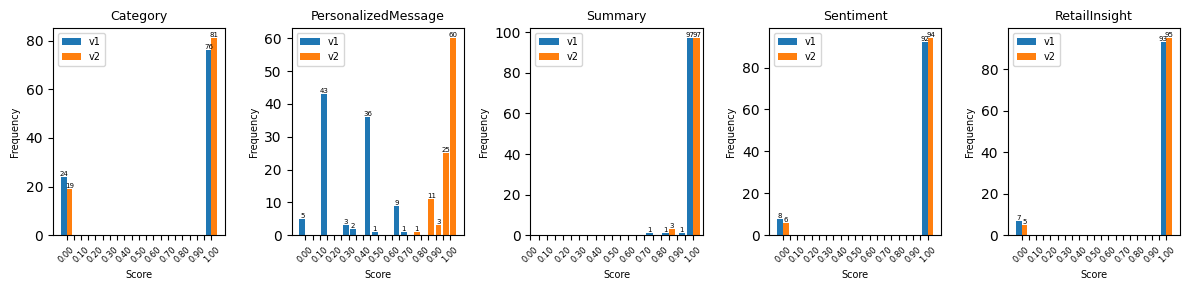

In [ ]:
# Comparison of scores V1 vs V2
plot_evaluation_comparison_histograms(CoT_v1_evaluations, CoT_v2_evaluations)

**Observation**
* 19 reviews with incorrect Category values comparing to inferred by LLM judge, a slight improvement from V1 with 24 incorrect Category values.  
* Personalized message shows the most significant improvement. Even without considering the penality for company name inclusion for V1, V2 still shows better quality for personalized message. 5 personalized message scored 0.0 from V1 while lowest score from V2 is 0.7. <br>
    * The following example shows clear improvement for identifying care instruction as the real issue and follow-ups in V2:<br>
          Review 5019:<br>
          **Text**: _I have wanted this dress since i first tried it on in april. finally got it as a birthday gift and after looking at it closely there was makeup on the collar. i checked the instructions and it says "cold water wash". so i washed only the collar part by hand and every part that got water on it bled!!! looks like the popsicles are melting! i'm so sad because this dress is adorable! i'm buying another in hopes retailer will make this right by taking back the first one. should be dry clean only!_<br>
          **V1**: _We’re very sorry for the issues you experienced with the dress and its care instructions. Our team will reach out to help resolve this for you._<br>
          **V2**: _We're very sorry to hear that the care instructions led to color bleeding on your dress. Please contact ChicStyle customer support so we can assist you with a return or exchange and help resolve this issue._<br>

* Sentiment and Urgency both improved from V1 to V2. Summary stays roughly the same.
* V2 score 0.932 is a significant improvement from 0.784 for V1. The above histogram comparision confirms the improvement in all 5 predictions/classifications. PersonalizedMessage receives the most significant improvement.

### **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?


#####Recommendation Prediction based on Review only

In [ ]:
# create a strictly two-line prompt
recommendation_prompt_template = """Based ONLY on this review text: {review}, output a binary recommendation (1 = recommend, 0 = not recommend).
Return STRICT JSON: {{"PredictedRecommendation": 1 or 0, "Reason": "<short reason under 15 words>"}}; no extra text."""
recommendation_prompt = ChatPromptTemplate.from_template(recommendation_prompt_template)

In [ ]:
review_only_input_column_map = {
    "Review": "review"
}
review_only_input_default_map = {
    "review": "[No comment]" # defalut value if no review
}
# create ReviewProcessor instance and set rate limit.
parser = JsonOutputParser()
review_processor = ReviewProcessor(llm, parser, review_only_input_column_map, review_only_input_default_map, calls=1, period=3)

In [ ]:
with ProcessTimer("Predicting recommendation based on review text only"):
    df_recommendation_predicted = review_processor.process_df_with_progress(df_sampled, recommendation_prompt, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Predicting recommendation based on review text only took 91.332200 seconds


#####Mismatched prediction and reasons for mismatch

In [ ]:
# convert boolean to 1/0 integer value
df_recommendation_predicted["Recommendation"] = df_recommendation_predicted["Recommended"].fillna(False).astype(int)
cols_to_show = ["original_index","Title","Review","Rating","Recommendation","PredictedRecommendation"]
# show rows where predicted value not equal to actual value for Recommendation
df_recommendation_mismatch = df_recommendation_predicted[df_recommendation_predicted.PredictedRecommendation!=df_recommendation_predicted.Recommendation][cols_to_show]
df_recommendation_mismatch

,original_index,Title,Review,Rating,Recommendation,PredictedRecommendation
4,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",3,1,0
11,1847,Great dress but...,Loved this dress and ordered it based on glowi...,3,1,0
20,12629,Maybe not for petites?,I ordered xs petite and was pretty excited whe...,4,1,0
36,3000,"Wants to be modern, but didnt get there.",I was hoping this top would be a nice architec...,4,1,0
40,13536,Beautiful but big and wide,"I should have known with the combined sizing, ...",4,1,0
44,12338,Average and plain,I agree with the first reviewer. this dress is...,3,1,0
45,7348,Terrible cut,These look nothing like the picture! they are ...,2,1,0
49,4107,Had to return,This top fit perfectly but too much of my bra ...,2,0,1
58,8847,Simple dress,"This is a cute dress, but just not a keeper fo...",3,1,0
63,23334,Not as pictured,I ordered the dress online and found it to be ...,3,1,0


**Observation**

* There is only one case where the incorrect prediction is 1, the associated review (index=4107) reads quite positive but with a rating of only 2. The review itself thus can be misleading for LLM without rating as extra input.
* For cases where the incorrect predictions are 0, the reviews reads with dominantly negative sentiment, causing LLM to think there should be no recommendation. This can be improved by adding rating as an extra input.

##### LLM explanation for mismatch

In [ ]:
recommendation_mismatch_reason_prompt = ChatPromptTemplate.from_template(
"""
You are an expert in analyzing discrepancies between human labels and model predictions in e-commerce review data.

Your task is to explain why a model’s PredictedRecommendation may differ from the human-labeled Recommendation using provided Title, Review text and Rating.

Be objective, precise, and evidence-based.

Do NOT speculate beyond the given input.
Do NOT assume the model or human is always correct.
Human Recommendation considers Title, Review text, and Rating.
Predicted Recommendation only considers Review text.
Focus on identifying signals in the review that justify each side.

Keep explanations concise and grounded in the text.

INPUT:
Title: {title}
Review: {review_text}
Rating: {rating}

Human Recommendation:
{human_recommendation}   # 1 = recommend, 0 = not recommend

Predicted Recommendation:
{predicted_recommendation}   # 1 = recommend, 0 = not recommend

====================================================
TASK
====================================================

Step 1: Identify key signals from the review
- Extract main positive aspects
- Extract main negative aspects
- Determine overall sentiment strength

Step 2: Interpret Human Recommendation
- Explain what signals likely led to the human decision
- Consider both review text and rating

Step 3: Interpret Predicted Recommendation
- Explain what signals the model likely relied on
- Identify if it focused on positive, negative, or mixed signals

Step 4: Explain the difference (CRITICAL)
- Why do the human and model disagree (if they do)?
- Is the review mixed, ambiguous, or imbalanced?
- Did one side overweight certain signals?

Step 5: Final judgment
- Which recommendation is better supported by the review?
- Or state if both are reasonable due to mixed signals

====================================================
OUTPUT FORMAT (STRICT JSON ONLY)
====================================================

{{
  "KeySignals": {{
    "Positive": ["..."],
    "Negative": ["..."]
  }},
  "HumanReasoning": "...",
  "ModelReasoning": "...",
  "DiscrepancyExplanation": "...",
  "BetterSupported": "Human | Model | Both",
  "Confidence": "High | Medium | Low"
}}
""")

In [ ]:
recommendation_comparison_input_column_map = {
    "Title":"title",
    "Review": "review_text",
    "Rating": "rating",
    "Recommendation": "human_recommendation",
    "PredictedRecommendation": "predicted_recommendation"
}
recommendation_comparison_input_default_map = {
    "title": "[No title]", # defalut value if no review
    "review_text": "[No comment]" # defalut value if no review
}
# create ReviewProcessor instance and set rate limit.
parser = JsonOutputParser()
recommendation_comparison_processor = ReviewProcessor(
    llm, parser, recommendation_comparison_input_column_map,
    recommendation_comparison_input_default_map, calls=1, period=3)

In [ ]:
with ProcessTimer("LLM comparison of Recommendation prediction"):
    df_recommendation_mismatch_reason = recommendation_comparison_processor.process_df_with_progress(
        df_recommendation_mismatch, recommendation_mismatch_reason_prompt, show_progress=True)

Processing reviews:   0%|          | 0/13 [00:00<?, ?it/s]

LLM comparison of Recommendation prediction took 69.228496 seconds


In [ ]:
df_recommendation_mismatch_reason[["Review","HumanReasoning","ModelReasoning","DiscrepancyExplanation"]]

,Review,HumanReasoning,ModelReasoning,DiscrepancyExplanation
4,"I love this blouse, i've received so many comp...",The human likely considered the strong positiv...,"The model, relying only on the review text, li...",The review is mixed: strong initial praise and...
11,Loved this dress and ordered it based on glowi...,The human likely considered both the positive ...,"The model, relying solely on the review text, ...","The review is mixed, containing both strong po..."
20,I ordered xs petite and was pretty excited whe...,The human likely considered the initial excite...,"The model, relying solely on the review text, ...",The disagreement arises because the human fact...
36,I was hoping this top would be a nice architec...,The human likely considered the relatively hig...,"The model, relying solely on the review text, ...",The discrepancy arises because the human label...
40,"I should have known with the combined sizing, ...",The human likely considered both the positive ...,"The model, relying solely on the review text, ...",The disagreement arises because the human fact...
44,I agree with the first reviewer. this dress is...,The human likely considered the overall mixed ...,"The model, relying solely on the review text, ...",The disagreement arises because the human fact...
45,These look nothing like the picture! they are ...,Despite the overwhelmingly negative review tex...,"The model, relying solely on the review text, ...",The discrepancy arises because the human label...
49,This top fit perfectly but too much of my bra ...,The human likely considered both the negative ...,"The model, using only the review text, likely ...",The disagreement arises because the review con...
58,"This is a cute dress, but just not a keeper fo...",The human likely considered the overall positi...,"The model, relying solely on the review text, ...",The review is mixed: it contains both positive...
63,I ordered the dress online and found it to be ...,"The human likely considered the 3-star rating,...","The model, relying solely on the review text, ...",The discrepancy arises because the human consi...


**Observation**

* LLM attributes mismatch most to mixed reviews and the fact that human labels include Rating and Title in addition to Review text.
    * Example:<br>
    **Review**: _I was hoping this top would be a nice architectural piece to add to my wardrobe with its straight black line accents. sadly, in the end, it is just a t-shirt. a large t-shirt. i ordered my normal size (medium) and this shirt ran more like a large. i also did not like the way the neck was hemmed. the fabric folds over itself, when i think a better design would have been a more simple hem. i ended up returning this item due to its size._<br>
    **Mismatch reason**: _The discrepancy arises because the human labeler incorporated the high rating (4), which typically signals satisfaction, while the model only had access to the review text, which is predominantly negative and concludes with a return. The review is mixed but leans negative in text, while the rating is positive, creating ambiguity. The human may have overweighted the rating, while the model overweighted the negative textual content._<br>

* This explanation is consistent with human explanation.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df_recommendation_predicted["Recommendation"], df_recommendation_predicted["PredictedRecommendation"]))

              precision    recall  f1-score   support

           0       0.76      0.97      0.86        40
           1       0.98      0.80      0.88        60

    accuracy                           0.87       100
   macro avg       0.87      0.89      0.87       100
weighted avg       0.89      0.87      0.87       100



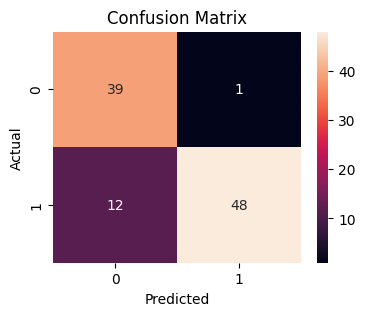

In [ ]:
from sklearn.metrics import confusion_matrix

labels = sorted(df_recommendation_predicted["Recommendation"].unique())
cm = confusion_matrix(df_recommendation_predicted["Recommendation"], df_recommendation_predicted["PredictedRecommendation"], labels=labels)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


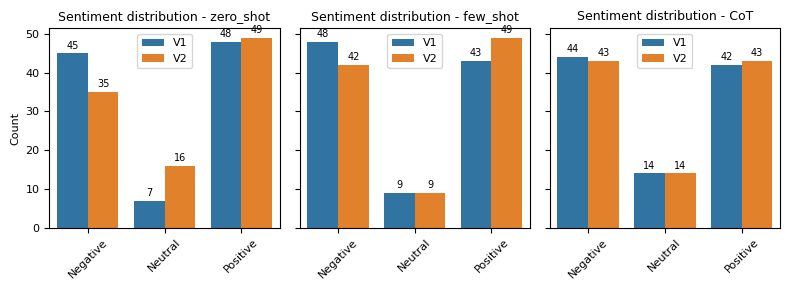

In [ ]:
# Histogram for predicted Sentiment: side-by-side V1 vs V2 for each prompt technique
sentiment_cols = {
    "zero_shot": {
        "v1": df_zero_shot_result_v1["Sentiment"], "v2": df_zero_shot_result_v2["Sentiment"],
    },
    "few_shot": {
        "v1": df_few_shot_result_v1["Sentiment"], "v2": df_few_shot_result_v2["Sentiment"],
    },
    "CoT": {
        "v1": df_CoT_result_v1["Sentiment"], "v2": df_CoT_result_v2["Sentiment"],
    },
}

order = ["Negative", "Neutral", "Positive"]
plot_df = pd.concat(
    [
        pd.DataFrame({
            "Technique": technique, "Version": version.upper(), "Sentiment": values
        })
        for technique, versions in sentiment_cols.items()
        for version, values in versions.items()
    ],
    ignore_index=True
)

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)
axes = axes.flatten()

for i, technique in enumerate(["zero_shot", "few_shot", "CoT"]):
    ax = axes[i]

    sns.countplot(
        data=plot_df[plot_df["Technique"] == technique],
        x="Sentiment",
        hue="Version",
        order=order,
        ax=ax
    )

    ax.set_title(f"Sentiment distribution - {technique}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Count" if i == 0 else "", fontsize=8)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(title="", fontsize=8)

    # 🔹 Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

In [ ]:
# We now compare how three techniques are different in sentiment prediction.
# Step 1: Rename columns to avoid collisions
df1 = df_zero_shot_result_v2.rename(columns={
    #"Category": "Category_zs",
    "Sentiment": "Sentiment_zs"
})

df2 = df_few_shot_result_v2.rename(columns={
    #"Category": "Category_fs",
    "Sentiment": "Sentiment_fs"
})

df3 = df_CoT_result_v2.rename(columns={
    #"Category": "Category_cot",
    "Sentiment": "Sentiment_cot"
})

# Step 2: Merge dataframes on original_index
df_merged = df1.merge(
    df2[["original_index", "Sentiment_fs"]],
    on="original_index"
).merge(
    df3[["original_index", "Sentiment_cot"]],
    on="original_index"
)

# Step 3: Find rows where Sentiment differ across models
mask_diff = df_merged[["Sentiment_zs", "Sentiment_fs", "Sentiment_cot"]].nunique(axis=1) > 1

df_diff = df_merged[mask_diff]

# Step 4: Select final columns for inspection
result = df_diff[[
    "original_index",
    "Title",
    "Review",
    "Rating",
    #"Category_zs", "Category_fs", "Category_cot",
    "Sentiment_zs", "Sentiment_fs", "Sentiment_cot"
]]

# Optional: reset index for clean display
result = result.reset_index(drop=True)

# Optional: number of disagreements
print(f"Total disagreement rows: {len(result)}")

# View result
result

Total disagreement rows: 14


,original_index,Title,Review,Rating,Sentiment_zs,Sentiment_fs,Sentiment_cot
0,19764,"Beautiful, poor quality","I love this blouse, i've received so many comp...",3,Neutral,Negative,Negative
1,16065,Beautiful pants that are way too big!,"I love the feel and quality of these pants, ho...",3,Neutral,Negative,Negative
2,15422,Not what i thought,I loved the look of this top when i saw it onl...,3,Neutral,Negative,Negative
3,19121,"Beautiful, dramatic trench, but impractical up...","This trench is beautiful, with a lovely, swing...",3,Neutral,Neutral,Negative
4,9088,Cute jeans,I really liked these jeans. i had to return th...,4,Positive,Positive,Neutral
5,1409,Much cuter in the picture,This top runs small across the top. i was amaz...,3,Neutral,Negative,Negative
6,11690,No shape,"I loved the idea of this dress, but i find tha...",3,Neutral,Negative,Negative
7,13536,Beautiful but big and wide,"I should have known with the combined sizing, ...",4,Positive,Positive,Neutral
8,18518,"Fun and gorgeous suit, but not for me",This was the first suit i've ever ordered onli...,4,Positive,Positive,Neutral
9,22401,Runs small,I'm 5'3 135lbs with hour-glassy figure and the...,4,Positive,Positive,Neutral


**Observation**


* Out of all 3 techniques, CoT performance (least variation) is the most robust between V1 and V2.
* Zero-shot and few-shot output slightly more positive sentiment predictions given that our sample has more high-rating records than low-rating records. CoT outputs the most balanced predictions and most number of Neutral predictions. Zero-shot & few-shot tend have less Neutral results and CoT.  
* Zero-shot and Few-shot (V1+V2), tend to predict less Neutral value when there is a mix of positive and negative feedbacks. CoT seems to be able to identify mixed sentiments and thus results more Neutral values, suggesting stronger ability to handle nuances.

    **Example** (index=19121):
        In this incomplete review, the customer is apparently not satisfied regardless of the compliments at the beginning. The rating of 3 also suggests that dominant tone should be negative. Both zero-shot and few-shot give the wrong classification of "Neutral".
        
    **Example** (index=22401):
        In this review, the sentiment should be "Neutral" even with a rating of 4 because "Fit" is the actual issue regardless of all the compliments.  But both zero-shot and few-shot give the wrong classification of "Positive".

###  **Comparison of Prompting Techniques:**

#### Sentiment Prediction Comparison
We now use LLM to compare sentiment prediction performance across the three prompting techniques.

In [ ]:
sentiment_comparison_prompt = ChatPromptTemplate.from_template(
"""
You are an expert in evaluating LLM prompting strategies for sentiment analysis.

Your task is to compare outputs from different prompting techniques (Zero-shot, Few-shot, and Chain-of-Thought) and determine which produces the most accurate and reliable outcome.

You must evaluate each prediction independently using ONLY the review text as ground truth.

Do NOT assume any prediction is correct.
Do NOT merge predictions.
Do NOT reuse reasoning from one prediction to justify another.

Focus on:
- alignment with the review text
- correctness of sentiment
- handling of mixed sentiment
- overall reliability of the prediction

You must also select the single best overall outcome among the three techniques.

INPUT:

Review: {review_text}

Predicted Sentiments:

- Zero-shot: {zero_shot_prediction}
- Few-shot: {few_shot_prediction}
- CoT: {cot_prediction}

====================================================
TASK
====================================================

Step 1: Infer the TRUE sentiment from the review.

Use these rules:
- Positive → clear satisfaction, praise, recommendation
- Negative → complaint, dissatisfaction, frustration
- Neutral → mixed sentiment OR no dominant emotion

Text sentiment ALWAYS overrides rating assumptions.

----------------------------------------------------

Step 2: Evaluate each prediction independently

For each method (Zero-shot, Few-shot, CoT):

- Compare prediction with the inferred true sentiment
- Assign a score:
  - 1.0 → exact match
  - 0.5 → partially correct (mixed sentiment misclassified as neutral, etc.)
  - 0.0 → incorrect

----------------------------------------------------

Step 3: Select the best technique

- Choose the method with the highest score
- If tie → prefer the one that better captures nuance (mixed sentiment, tone)

----------------------------------------------------

Step 4: Provide reasoning

- Briefly explain:
  - why the true sentiment was chosen
  - why the best method is better than the others

====================================================
OUTPUT FORMAT (STRICT JSON ONLY)
====================================================

{{
  "TrueSentiment": "Positive | Negative | Neutral",
  "Scores": {{
    "ZeroShot": 0.0,
    "FewShot": 0.0,
    "CoT": 0.0
  }},
  "BestMethod": "ZeroShot | FewShot | CoT",
  "Reason": "Concise explanation of decision"
}}
""")

In [ ]:
# create a dataframe to include sentiment predictions for all three techniques using v2 results
df_sentiment_comparison = df_zero_shot_result_v2[["Review", "Sentiment", "original_index"]].rename(columns={"Sentiment": "ZeroShotPrediction"})
df_sentiment_comparison = df_sentiment_comparison.merge(
    df_few_shot_result_v2[["Sentiment", "original_index"]].rename(columns={"Sentiment": "FewShotPrediction"}),
    on="original_index",how="inner"
)
df_sentiment_comparison = df_sentiment_comparison.merge(
    df_CoT_result_v2[["Sentiment", "original_index"]].rename(columns={"Sentiment": "CoTPrediction"}),
    on="original_index",how="inner"
)

In [ ]:
review_comparison_input_column_map = {
    "Review": "review_text",
    "ZeroShotPrediction": "zero_shot_prediction",
    "FewShotPrediction": "few_shot_prediction",
    "CoTPrediction": "cot_prediction",
}
review_comparison_input_default_map = {
    "review_text": "[No comment]" # defalut value if no review
}
# create ReviewProcessor instance and set rate limit.
parser = JsonOutputParser()
review_comparison_processor = ReviewProcessor(llm, parser, review_comparison_input_column_map, review_comparison_input_default_map, calls=1, period=3)

In [ ]:
with ProcessTimer("Comparing sentiment prediction across three techniques based on review text only"):
    df_sentiment_comparison_result = review_comparison_processor.process_df_with_progress(df_sentiment_comparison, sentiment_comparison_prompt, show_progress=True)

Processing reviews:   0%|          | 0/100 [00:00<?, ?it/s]

Comparing sentiment prediction across three techniques based on review text only took 184.094039 seconds


In [ ]:
# average scores
df_sentiment_comparison_result[["Scores.ZeroShot","Scores.FewShot","Scores.CoT"]].mean()

,0
Scores.ZeroShot,0.820
Scores.FewShot,0.890
Scores.CoT,0.935


**Conclusion**

    Per LLM judge, Chain-of-Thought clearly performs the best in sentiment prediction.

#### Overall Performance Comparison by LLM Judge

LLM-judge evaluation score (v1 vs v2)

    | Model            | V1     | V2     |
    |----------------- |--------|--------|
    | Chain-of-Thought | 0.784  | 0.932  |
    | Few-shot         | 0.780  | 0.929  |
    | Zero-shot        | 0.772  | 0.906  |

We use a reference-free LLM judge and ask to compare prediction with internally inferred values based the judge prompt. A prediction prompt closer to the judge prompt in the inferring will likely score higher. Thus a reference-free LLM judge is more suitable for pair-wise comparison between different versions of the same technique. To establish an absolute baseline across different techniques, a groud truth dataset as baseline is a better approach. However, a groud truth approach is not scalable with large number of reviews.   
    
   *  How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        * For each technique, V2 is usually better than V1, which is expected due to more structed rules.
        * Overall performance, CoT > Few-Shot > Zero-Shot.
        
   *  Which technique was the most reliable and consistent? Why do you think it performed the best?

      Out of the 3 techniques, CoT is the best. It forces intermediate structure. Without CoT, models often jump straight to an answer. That increases:

      * shortcut reasoning
      * pattern matching
      * hidden assumption errors

      CoT breaks this into steps like:
      infer → compare → decide → explain
       
   *   What model and prompt design would you propose for a production environment?
        
       * Based on the above experiment and analysis, CoT is recommended for a production environment.

#### **Observations and Insights**

**Refined Insights:**
    
Most meaningful and recurring insights from the customer reviews, as identified in all models.

* Size is the most common issue in the sampled low-rating reviews.
* Negative sentiment and low-rating leads to high urgency for retail insight.  
* Predicted sentiment is negatively correlated with rating, the lower rating the higher chance of Negative sentiment.
* Sentiment is also highly correlated with Urgency. Negative sentiment often results high urgency. This is acutally consistent with what is prescribed in all prompts of different techniques.  



## Generating Actionable Product Improvement Suggestions

### Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?

We use LLM to generate business strategy based on findings.

In [ ]:
business_strategy_system_prompt = """
You are a senior retail business strategist specializing in customer experience, product optimization, and AI-driven insights.

Your role is to translate analytical findings (including LLM prompt evaluation results and customer review insights) into clear, practical business strategies.

Focus on:
- revenue impact
- customer satisfaction
- operational feasibility
- prioritization and actionability

Avoid generic advice. Ground every recommendation in the provided findings.

Be concise, structured, and business-oriented.
"""

business_strategy_user_prompt = """
INPUT:

Business Context:
<<<{business_context}>>>

Business Objective:
<<<{business_objective}>>>

Prompt Technique Evaluation Findings:
<<<{prompt_evaluation_findings}>>>
# (e.g., CoT improves sentiment accuracy, Few-shot improves consistency, Zero-shot is fastest but less reliable)

Customer Review Findings:
<<<{customer_review_findings}>>>
# (e.g., common complaints, praise patterns, category issues)

====================================================
TASK
====================================================

Step 1: Synthesize Key Insights
- Identify 2–4 most important business-relevant insights
- Link prompt performance to business impact (e.g., better sentiment → better CX decisions)

Step 2: Identify Opportunity Areas
- Customer experience improvements
- Product or merchandising changes
- Operational or process improvements
- AI/LLM deployment opportunities

Step 3: Generate Actionable Recommendations

Provide:
- 3 Short-Term recommendations (3–6 months)
- 3 Long-Term recommendations (6–12 months)

Each recommendation MUST include:
- Action (what to do)
- Rationale (why it matters based on inputs)
- Expected impact (business outcome)
- Priority (High / Medium / Low)

Guidelines:
- Be specific and actionable (not generic)
- Tie directly to findings
- Balance quick wins vs strategic investments
- Avoid repeating the same idea in different wording

====================================================
OUTPUT FORMAT (STRICT)
====================================================

{{
  "KeyInsights": [
    "...",
    "...",
    "..."
  ],
  "ShortTermRecommendations": [
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }},
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }},
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }}
  ],
  "LongTermRecommendations": [
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }},
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }},
    {{
      "Action": "...",
      "Rationale": "...",
      "ExpectedImpact": "...",
      "Priority": "High | Medium | Low"
    }}
  ]
}}"""

In [ ]:
business_context="""
ChicStyle — a growing fashion retail platform — experiences massive spikes in customer activity during festive seasons and holiday sales. As people buy clothing and accessories for celebrations, the volume of incoming reviews increases drastically. These reviews pour in every hour, ranging from positive praise to urgent complaints about fit, delivery delays, product defects, or sizing issues.During such high-pressure periods, even a slight delay in reading or responding to customer feedback can have serious consequences. If the retail team fails to take quick action, customers may feel ignored during an emotionally significant time (festive purchases), leading to frustration, spoiled shopping experiences, and ultimately reduced trust in the brand. This not only results in immediate business loss but also impacts repeat purchases and long-term loyalty. To avoid customer dissatisfaction and protect brand reputation during peak sales periods, ChicStyle needs a system that can process thousands of reviews instantly, accurately, and with business context.
"""

business_objective="""
Build a Generative AI feedback system that uses prompt engineering(Zero-Shot,Few-Shot,and Chain-of-Thought prompting)to:

* Analyze and categorize sentiment in real time.
* Detect which product or service each feedback refers to.
* Summarize insights by product category and urgency level.
* Automatically send short personalized messages to customers based on sentiment—thanking them for positive feedback, acknowledging neutral comments,and apologizing for negative ones while informing them that a team member will reach out soon.
* Generate short, actionable reports for retail teams.This intelligent system will help retailers take quick action on customer issues,improve product quality faster,and enhance customer satisfaction—turning massive unstructured feedback into meaningful,real-time business intelligence.
"""

prompt_evaluation_findings = """
LLM-judge evaluation score (v1 vs v2)

    | Model            | V1     | V2     |
    |----------------- |--------|--------|
    | Chain-of-Thought | 0.784  | 0.932  |
    | Few-shot         | 0.780  | 0.929  |
    | Zero-shot        | 0.772  | 0.906  |

We use a reference-free LLM judge and ask to compare prediction with internally inferred values based the judge prompt. A prediction prompt closer to the judge prompt in the inferring will likely score higher. Thus a reference-free LLM judge is more suitable for pair-wise comparison between different versions of the same technique. To establish an absolute baseline across different techniques, a groud truth dataset as baseline is a better approach. However, a groud truth approach is not scalable with large number of reviews.

   *  How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        * For each technique, V2 is usually better than V1, which is expected due to more structed rules.
        * Overall performance, CoT > Few-Shot > Zero-Shot.

   *  Which technique was the most reliable and consistent? Why do you think it performed the best?

      Out of the 3 techniques, CoT is the best. It forces intermediate structure. Without CoT, models often jump straight to an answer. That increases:

      * shortcut reasoning
      * pattern matching
      * hidden assumption errors

      CoT breaks this into steps like:
      infer → compare → decide → explain

   *   What model and prompt design would you propose for a production environment?

   * Based on the above experiment and analysis, CoT is recommended for a production environment.
"""


customer_review_findings = """
Most meaningful and recurring insights from the customer reviews, as identified in all models.

1. Size is the most common issue in the sampled low-rating reviews.
2. Negative sentiment and low-rating leads to high urgency for retail insight.
3. Predicted sentiment is negatively correlated with rating, the lower rating the higher chance of Negative sentiment.
4. Sentiment is also highly correlated with Urgency. Negative sentiment often results high urgency. This is acutally consistent with what is prescribed in all prompts of different techniques.
"""

In [ ]:

# Call the LLM with the business_prompt to generate strategic recommendations.
messages=[
    {"role": "system", "content": business_strategy_system_prompt },
    {"role": "user", "content": business_strategy_user_prompt}
]
business_strategy_prompt = ChatPromptTemplate.from_messages(messages)
business_strategy_llm_chain =  business_strategy_prompt | llm | parser
business_strategy_result = business_strategy_llm_chain.invoke(
    {"business_context": business_context,
     "business_objective": business_objective,
     "prompt_evaluation_findings": prompt_evaluation_findings,
     "customer_review_findings": customer_review_findings})


In [ ]:
pd.DataFrame(business_strategy_result['KeyInsights'])

,0
0,"Chain-of-Thought (CoT) prompting delivers the highest accuracy and reliability in sentiment and urgency detection, directly enabling faster and more precise customer issue triage during peak periods."
1,"Sizing issues are the most frequent cause of negative reviews and high-urgency complaints, indicating a clear product-level pain point impacting customer satisfaction and repeat business."
2,"Negative sentiment is strongly correlated with both low ratings and high urgency, making real-time detection and escalation of such feedback critical for protecting brand reputation and revenue during high-traffic events."


In [ ]:
# Show full column content (no truncation)
pd.set_option('display.max_colwidth', None)
# Show full width (avoid wrapping into truncated view)
pd.set_option('display.width', None)

In [ ]:
pd.DataFrame(business_strategy_result['ShortTermRecommendations'])

,Action,Rationale,ExpectedImpact,Priority
0,Deploy a CoT-based Generative AI feedback system for real-time review analysis and automated customer messaging during peak sales periods.,"CoT outperforms other prompt techniques in accuracy and reliability, ensuring urgent issues are flagged and customers receive timely, context-aware responses.","Reduces customer churn, increases satisfaction, and prevents reputational damage by addressing high-urgency complaints swiftly.",High
1,Implement automated escalation workflows for reviews flagged as high-urgency negative sentiment (especially those mentioning sizing or delivery issues).,"Negative, urgent feedback is most damaging if ignored; automation ensures no critical complaint is missed during volume spikes.",Minimizes lost sales and negative word-of-mouth by guaranteeing rapid human follow-up on the most impactful issues.,High
2,"Launch a targeted review of top-selling SKUs with frequent sizing complaints and update product descriptions, size guides, and imagery accordingly.",Sizing is the most common source of dissatisfaction; immediate improvements in product information can reduce returns and negative reviews.,Boosts conversion rates and reduces costly returns by setting clearer customer expectations.,Medium


In [ ]:
pd.DataFrame(business_strategy_result['LongTermRecommendations'])

,Action,Rationale,ExpectedImpact,Priority
0,"Integrate AI-driven insights into product development and merchandising cycles, prioritizing redesigns or supplier changes for SKUs with persistent sizing or quality complaints.","Systematic feedback analysis enables data-driven product improvements, addressing root causes of dissatisfaction.","Improves product quality, reduces negative sentiment over time, and strengthens brand loyalty.",High
1,Develop a closed-loop feedback system where resolved high-urgency cases trigger follow-up surveys and loyalty incentives for affected customers.,Turning negative experiences into positive ones can recover trust and drive repeat purchases.,Increases customer lifetime value and positive review rates by demonstrating proactive care.,Medium
2,"Continuously refine and retrain the AI feedback system using post-event data, including actual resolution outcomes and customer satisfaction scores.",Ongoing model improvement ensures the system adapts to changing customer language and business needs.,"Maintains high accuracy and relevance of insights, supporting sustained operational excellence.",Medium


#### Observations and Insights

* We use a reference-free llm-judge for evaluation. A more robust approach is to use ground truth to establish a baseline and to use historical response dataset to continously evaluate and update pipeline/prompts to improve prediction quality. Evaluation with ground truth is more robust and objective with low variance.
* In the short-term (3-6 month), using GenAI pipeline to assist in processing reviews with human supervision while collecting curated and approved human responses.
* In the long term (6-12 month), can use actual resolution outcomes (ground truth) to build a RAG system to further ground the responses of GenAI pipeline and fully automate the whole process.

### How does this automated GenAI pipeline solve the initial business problem and create value?

#### **Observations and Insights**


* The automated GenAI pipeline is able to quicky identify review Category(feedback types), gauge review sentiment and sense of urgency and create proper personalized message for post-sale team to review or even competely automate the process for sending high-urgency responses, thus improving turn-around time and customer care quality.

### **Conclusion**

* When fixed rules do not work well along with limited training data, GenAI models are better option than tranditional ML models to efficiently handle business complexity and ambiguity.
* A GenAI solution can potentially cost more than traditional modles due to costly LLM service provider cost.(Had to switch to paid personal account due to running out of quota with the given key.)